In [5]:
# A1 - Leaflet-symmetry distribution convergence probe (independent cell)
#
# Per-analog: two exact sign-flip permutation tests over the 9 200-ns blocks.
#   (1) Population, studentized. Statistic T_pop = |mean(Delta N)| / SE(Delta N)
#       with Delta N_block = 26 * (sum_{|z|<=Z_ABS_MAX_A} P_up - sum P_down).
#       SE is recomputed inside each sign pattern so block-to-block variance
#       enters both the observed T and the null. Exact 2^9 = 512 patterns.
#   (2) Shape, omnibus max-t. Statistic T_shape = max_z |mean_block(P_up-P_down)|
#       / SE_block(P_up-P_down). The same 512 patterns are applied jointly to
#       every |z| bin so within-block covariance is preserved and the test
#       controls the family-wise error over bins without an extra Bonferroni.
#
# Cross-analog: Benjamini-Hochberg FDR on the 28 population p-values and the 28
# shape p-values independently, at q = ALPHA. Overall pass/flag is gated on the
# BH q-values, not the raw p-values.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

MOLECULES_PER_SYSTEM = 26
SIGNIFICANCE_THRESHOLD = 0.5 / MOLECULES_PER_SYSTEM
ALPHA = 0.05
PLATEAU_MAX_A = 19.5
Z_ABS_MAX_A = 50.0  # folded-depth cutoff applied to both population and shape statistics
ANALOGS = {
    "sca":"ALA", "scv":"VAL", "scl":"LEU", "sci":"ILE", "scm":"MET", "scc":"CYS0",
    "scs":"SER", "sct":"THR", "scn":"ASN", "scq":"GLN", "scf":"PHE", "scy":"TYR0",
    "scw":"TRP", "scp":"PRO", "glyd":"GLYD", "scdn":"ASP0", "scen":"GLU0", "sche":"HSE0",
    "schd":"HSD0", "sckn":"LYS0", "scrn":"ARG0", "scd":"ASP-", "sce":"GLU-", "sccm":"CYS-",
    "scym":"TYR-", "schp":"HSP+", "sck":"LYS+", "scr":"ARG+",
}

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/distribution_data/total").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def sample_se(values):
    values = pd.Series(values).dropna()
    return values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else np.nan

_sign_pattern_cache = {}
def sign_patterns(n):
    if n not in _sign_pattern_cache:
        idx = np.arange(1 << n, dtype=np.int64)[:, None]
        _sign_pattern_cache[n] = (((idx >> np.arange(n)) & 1) * 2 - 1).astype(np.int8)
    return _sign_pattern_cache[n]

def population_permutation(values):
    x = np.asarray(values, dtype=float)
    n = x.size
    if n < 2 or np.var(x, ddof=1) == 0:
        return np.nan, np.nan, 0
    S = sign_patterns(n)
    signed = S * x
    perm_mean = signed.mean(axis=1)
    perm_se = np.sqrt(signed.var(axis=1, ddof=1) / n)
    with np.errstate(divide="ignore", invalid="ignore"):
        perm_t = np.where(perm_se > 0, np.abs(perm_mean) / perm_se, 0.0)
    obs_t = abs(float(x.mean())) / float(np.sqrt(np.var(x, ddof=1) / n))
    return float((perm_t >= obs_t - 1e-12).mean()), float(obs_t), int(S.shape[0])

def shape_maxt_permutation(matrix):
    """matrix: (n_blocks, n_bins). Two-sided omnibus max-|studentized-mean| test."""
    X = np.asarray(matrix, dtype=float)
    if X.ndim != 2 or X.shape[0] < 2 or X.shape[1] == 0:
        return np.nan, np.nan, -1, 0
    n, m = X.shape
    S = sign_patterns(n)
    signed = S[:, :, None] * X[None, :, :]                # (P, n, m)
    perm_mean = signed.mean(axis=1)                       # (P, m)
    perm_se = np.sqrt(signed.var(axis=1, ddof=1) / n)     # (P, m)
    with np.errstate(divide="ignore", invalid="ignore"):
        perm_t = np.where(perm_se > 0, np.abs(perm_mean) / perm_se, 0.0)
    perm_maxt = perm_t.max(axis=1)                        # (P,)
    obs_mean = X.mean(axis=0)
    obs_se = np.sqrt(X.var(axis=0, ddof=1) / n)
    with np.errstate(divide="ignore", invalid="ignore"):
        obs_t = np.where(obs_se > 0, np.abs(obs_mean) / obs_se, 0.0)
    idx = int(np.argmax(obs_t))
    return float((perm_maxt >= float(obs_t[idx]) - 1e-12).mean()), float(obs_t[idx]), idx, int(S.shape[0])

def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    n = p.size
    order = np.argsort(p)
    q_sorted = p[order] * n / (np.arange(n) + 1)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.minimum(q_sorted, 1.0)
    q = np.empty_like(q_sorted)
    q[order] = q_sorted
    return q

ROOT = find_repo_root()
INPUT = ROOT / "figures/data/distribution_data/total"
OUT = ROOT / "rev2/leaflet_symmetry"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# ---- Per-analog independent analysis ----
summary_rows, curve_rows = [], []
for code, analog in ANALOGS.items():
    block_curves, scalar_rows = [], []
    for trajectory in range(1, 4):
        path = INPUT / code / f"trajectory{trajectory}.dat"
        frame = pd.read_csv(path, sep=r"\s+")
        z = frame.iloc[:, 0].to_numpy(float)
        upper_mask = z > 0
        lower_mask = z < 0
        depth_up = z[upper_mask]
        depth_down = -z[lower_mask]
        up_order = np.argsort(depth_up)
        down_order = np.argsort(depth_down)
        depth_up = depth_up[up_order]
        depth_down = depth_down[down_order]
        for block_index, column in enumerate(frame.columns[1:4], 1):
            density = frame[column].to_numpy(float)
            raw_up = density[upper_mask][up_order]
            raw_down = density[lower_mask][down_order]
            depth_up_keys = np.round(depth_up, 6)
            depth_down_keys = np.round(depth_down, 6)
            common = np.intersect1d(depth_up_keys, depth_down_keys)
            common = common[(common >= 0) & (common <= Z_ABS_MAX_A)]
            if common.size == 0:
                continue
            up_index = np.searchsorted(depth_up_keys, common)
            down_index = np.searchsorted(depth_down_keys, common)
            block = pd.DataFrame({
                "z": common,
                "P_up": raw_up[up_index],
                "P_down": raw_down[down_index],
            })
            block["signed_gap"] = block["P_up"] - block["P_down"]
            block["gap"] = block["signed_gap"].abs()
            block["both_sampled"] = (block["P_up"] > 0) & (block["P_down"] > 0)
            block["replica"], block["block"] = trajectory, block_index
            block_curves.append(block)
            informative = block[(block["P_up"] > 0) | (block["P_down"] > 0)]
            if informative.empty:
                continue
            idx_max = informative["gap"].idxmax()
            scalar_rows.append({
                "max_bin_gap": float(block.loc[idx_max, "gap"]),
                "zstar": float(block.loc[idx_max, "z"]),
                "P_up_total": float(block["P_up"].sum()),
                "P_down_total": float(block["P_down"].sum()),
                "signed_delta_N": MOLECULES_PER_SYSTEM * float(block["P_up"].sum() - block["P_down"].sum()),
                "rms_gap": float(np.sqrt(np.mean(informative["gap"] ** 2))),
            })
    n_valid_blocks = len(scalar_rows)
    if n_valid_blocks == 0:
        raise RuntimeError(f"{analog}: no blocks with non-empty leaflet histograms")
    scalars = pd.DataFrame(scalar_rows)
    row = {"analog": analog, "n_valid_blocks": n_valid_blocks}
    for metric in ["max_bin_gap", "rms_gap", "zstar", "P_up_total", "P_down_total", "signed_delta_N"]:
        row[f"{metric}_mean"] = scalars[metric].mean()
        row[f"{metric}_se"] = sample_se(scalars[metric])
    row["max_bin_gap_molecules_mean"] = row["max_bin_gap_mean"] * MOLECULES_PER_SYSTEM
    row["max_bin_gap_molecules_se"] = row["max_bin_gap_se"] * MOLECULES_PER_SYSTEM

    # Test 1: studentized sign-flip permutation on Delta N_block.
    delta_values = scalars["signed_delta_N"].to_numpy(float)
    p_pop, T_pop, n_perm_pop = population_permutation(delta_values)
    row["T_population"] = T_pop
    row["p_population"] = p_pop
    row["n_perm_population"] = n_perm_pop

    combined = pd.concat(block_curves, ignore_index=True)
    curve = combined.groupby("z").agg(
        P_up_mean=("P_up", "mean"), P_up_se=("P_up", sample_se),
        P_down_mean=("P_down", "mean"), P_down_se=("P_down", sample_se),
        gap_mean=("gap", "mean"), gap_se=("gap", sample_se),
        signed_gap_mean=("signed_gap", "mean"), signed_gap_se=("signed_gap", sample_se),
        n_blocks_both_sampled=("both_sampled", "sum"),
        n_blocks=("gap", "count"),
    ).reset_index()

    # Test 2: omnibus max-|studentized-mean| sign-flip permutation across bins.
    complete = combined.groupby("z")["signed_gap"].apply(lambda s: len(s) == n_valid_blocks)
    complete_z = complete[complete].index.to_numpy()
    if complete_z.size > 0:
        signed_matrix = (
            combined[combined["z"].isin(complete_z)]
            .pivot_table(index=["replica", "block"], columns="z", values="signed_gap")
            .sort_index()
            .to_numpy(float)
        )
        p_shape, T_shape, arg_idx, n_perm_shape = shape_maxt_permutation(signed_matrix)
        zstar_shape = float(complete_z[arg_idx]) if arg_idx >= 0 else np.nan
        n_bins_tested = int(signed_matrix.shape[1])
    else:
        p_shape, T_shape, zstar_shape, n_perm_shape, n_bins_tested = np.nan, np.nan, np.nan, 0, 0
    row["T_shape"] = T_shape
    row["zstar_shape"] = zstar_shape
    row["n_bins_tested"] = n_bins_tested
    row["p_shape"] = p_shape
    row["n_perm_shape"] = n_perm_shape

    row["descriptive_flag"] = (row["max_bin_gap_mean"] - row["max_bin_gap_se"]) > SIGNIFICANCE_THRESHOLD
    summary_rows.append(row)

    curve.insert(0, "analog", analog)
    curve_rows.append(curve)

    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    solid = curve["n_blocks_both_sampled"] == n_valid_blocks
    for mean_col, se_col, label, color in [
        ("P_up_mean", "P_up_se", "Upper leaflet P(|z|)", "#176B87"),
        ("P_down_mean", "P_down_se", "Lower leaflet P(|z|) reflected", "#D1495B"),
        ("gap_mean", "gap_se", "|P_up - P_down|", "#2F4858"),
    ]:
        ax.plot(curve.loc[solid, "z"], curve.loc[solid, mean_col], color=color, label=label)
        ax.fill_between(
            curve.loc[solid, "z"],
            curve.loc[solid, mean_col] - curve.loc[solid, se_col],
            curve.loc[solid, mean_col] + curve.loc[solid, se_col],
            color=color, alpha=.15,
        )
        ax.plot(curve.loc[~solid, "z"], curve.loc[~solid, mean_col], color=color, linestyle="--", alpha=0.9)
    ax.axhline(SIGNIFICANCE_THRESHOLD, color="0.4", linewidth=.8, linestyle=":", label="0.5 molecule / bin (descriptive)")
    ax.axvspan(0, PLATEAU_MAX_A, color="0.92", zorder=0, label=f"|z| < {PLATEAU_MAX_A:g} A (plateau-prone)")
    ax.set(xlabel="Depth |z| (A)", ylabel="Normalized density (per-bin probability)", title=f"{analog}: leaflet symmetry")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES / f"leaflet_diff_vs_z_{analog}.png", dpi=600, bbox_inches="tight")
    plt.close(fig)

summary = pd.DataFrame(summary_rows)

# ---- Cross-analog analysis: Benjamini-Hochberg FDR ----
summary["q_population_bh"] = bh_fdr(summary["p_population"].to_numpy())
summary["q_shape_bh"] = bh_fdr(summary["p_shape"].to_numpy())
summary["population_test"] = np.where(summary["q_population_bh"] >= ALPHA, "pass", "flag")
summary["shape_test"] = np.where(summary["q_shape_bh"] >= ALPHA, "pass", "flag")
summary["overall_pass"] = np.where(
    (summary["population_test"] == "pass")
    & (summary["shape_test"] == "pass")
    & (summary["n_valid_blocks"] == 9),
    "pass", "flag",
)

# ---- Reorganized column layout ----
summary = summary[[
    "analog", "n_valid_blocks",
    # Effect size
    "signed_delta_N_mean", "signed_delta_N_se",
    "max_bin_gap_mean", "max_bin_gap_se",
    "max_bin_gap_molecules_mean", "max_bin_gap_molecules_se",
    "zstar_mean", "zstar_se",
    "rms_gap_mean", "rms_gap_se",
    "P_up_total_mean", "P_down_total_mean",
    # Population test (studentized sign-flip permutation)
    "T_population", "p_population", "n_perm_population", "q_population_bh", "population_test",
    # Shape test (omnibus max-t sign-flip permutation)
    "T_shape", "zstar_shape", "n_bins_tested", "p_shape", "n_perm_shape", "q_shape_bh", "shape_test",
    # Descriptive (informational only)
    "descriptive_flag",
    # Verdict
    "overall_pass",
]]
curves = pd.concat(curve_rows, ignore_index=True)
summary.to_csv(OUT / "leaflet_symmetry_summary.csv", index=False)
curves.to_csv(OUT / "per_analog_leaflet_diff_curves.csv", index=False)

pvalue_table = summary[[
    "analog",
    "signed_delta_N_mean", "signed_delta_N_se",
    "T_population", "p_population", "q_population_bh",
    "T_shape", "zstar_shape", "p_shape", "q_shape_bh",
    "population_test", "shape_test", "overall_pass",
]].copy()
pvalue_table.to_csv(OUT / "leaflet_symmetry_pvalues.csv", index=False)

flagged_pop = summary.loc[summary["population_test"] == "flag", "analog"].tolist()
flagged_shape = summary.loc[summary["shape_test"] == "flag", "analog"].tolist()
flagged_overall = summary.loc[summary["overall_pass"] == "flag", "analog"].tolist()
passed_overall = summary.loc[summary["overall_pass"] == "pass", "analog"].tolist()
incomplete = summary.loc[summary["n_valid_blocks"] < 9, ["analog", "n_valid_blocks"]]
incomplete_text = ", ".join(f"{row.analog} ({row.n_valid_blocks}/9)" for row in incomplete.itertuples()) or "none"

report = [
    "# Leaflet-symmetry distribution convergence",
    "",
    "## Data and estimator",
    "",
    "Depth-resolved densities are read directly from `figures/data/distribution_data/total/`. Each 200 ns column is a per-molecule, frame-averaged probability density on the z-axis: `P(z) dz` is the probability that a randomly selected (molecule, frame) has its z-coordinate in `[z, z + dz]`. Each column sums to ~1 across the full z range with `dz = 1 A`, so the mean per-frame number of molecules in a 1 A bin at depth z is `<n(z)> = 26 * P(z)`. The upper leaflet uses `z > 0` and the lower leaflet uses `z < 0` reflected onto `|z| >= 0`.",
    "",
    f"Both statistical tests are evaluated over the folded-depth window `|z| <= {Z_ABS_MAX_A:g} A`. The ~5-6% of probability mass falling outside that window is dropped from the block-level sums, so `P_up_total + P_down_total` is slightly below 1 by design. Block-level statistics use the nine independent 200 ns blocks (three replicas x three blocks). Sample means and SE use `ddof = 1` and `SE = s / sqrt(n_valid_blocks)`.",
    "",
    f"Incomplete valid-block sets: {incomplete_text}.",
    "",
    "## Two statistical tests per analog",
    "",
    "Because n = 9 blocks is too few to invoke normality, both tests are exact sign-flip permutation tests. Under H0 the upper and lower leaflets are exchangeable, so each block-level signed statistic has a distribution symmetric around zero and its sign can be flipped freely. With `n = 9` all `2^9 = 512` sign patterns are enumerated exactly, so the minimum achievable two-sided p-value is `2 / 512 ~= 0.0039`.",
    "",
    "**(1) Population test.** For each block we integrate the leaflet imbalance,",
    f"`Delta N_block = 26 * (sum_{{|z| <= {Z_ABS_MAX_A:g}}} P_up - sum_{{|z| <= {Z_ABS_MAX_A:g}}} P_down)`, and use the studentized statistic `T_pop = |mean(Delta N)| / SE(Delta N)` with `SE = s / sqrt(9)`. Both mean and SE are recomputed inside every sign pattern, so block-to-block variance contributes to the null distribution as well as to the observed value; this makes the population test comparable across analogs with very different block variances.",
    "",
    "**(2) Shape test.** For each block we also form the per-bin signed gap `d(|z|) = P_up(|z|) - P_down(|z|)` and compute the omnibus statistic `T_shape = max_z |mean_block(d)| / SE_block(d)`. The same 512 sign patterns are applied jointly to all bins per permutation, which preserves the within-block covariance and corrects the multiplicity across bins by construction (no separate Bonferroni is applied). `zstar_shape` is the |z| where the observed maximum occurs.",
    "",
    "## Cross-analog analysis",
    "",
    f"The 28 population p-values and the 28 shape p-values are separately adjusted for the number of analogs by the Benjamini-Hochberg step-up procedure, yielding `q_population_bh` and `q_shape_bh`. An analog **passes** its population/shape test when the corresponding BH q-value is >= {ALPHA}; otherwise it is flagged. `overall_pass` requires both tests to pass and all nine blocks to be present.",
    "",
    "## Descriptive effect size (informational only)",
    "",
    f"For interpretability the analysis retains the maximum per-bin gap `max_bin_gap` in native normalized units and its molecule-scaled version `max_bin_gap * MOLECULES_PER_SYSTEM`. A conservative visualization tolerance of `0.5 molecule / bin`, i.e. `|P_up - P_down| < 1 / (2 * MOLECULES_PER_SYSTEM) ~ {SIGNIFICANCE_THRESHOLD:.4f}`, is drawn as a dotted line on the per-analog plots. The `descriptive_flag` column indicates whether the observed effect exceeds this line; it is not used to gate pass/flag.",
    "",
    "## Results",
    "",
    f"Overall pass ({len(passed_overall)}/28): {', '.join(passed_overall) or 'none'}.",
    f"Overall flag ({len(flagged_overall)}/28): {', '.join(flagged_overall) or 'none'}.",
    "",
    f"Population BH-flagged (q_population_bh < {ALPHA}): {', '.join(flagged_pop) or 'none'}.",
    f"Shape BH-flagged (q_shape_bh < {ALPHA}): {', '.join(flagged_shape) or 'none'}.",
    "",
    "Note: adjacent blocks within a replica share the same physical trajectory and are therefore not strictly independent draws. The tests are conservative in the direction of *not* over-rejecting when the effective sample size is smaller than nine.",
    "",
    "Curves in the per-analog figures are drawn solid where all valid blocks contributed real samples in both leaflets and dashed where at least one block had a zero-sample leaflet in that bin.",
]
(OUT / "REPORT.md").write_text("\n".join(report), encoding="utf-8")

print("Per-analog leaflet-symmetry tests with BH-FDR across the 28 analogs:")
display(pvalue_table)
print()
print("Full leaflet-symmetry summary:")
display(summary)


Per-analog leaflet-symmetry tests with BH-FDR across the 28 analogs:


,analog,signed_delta_N_mean,signed_delta_N_se,T_population,p_population,q_population_bh,T_shape,zstar_shape,p_shape,q_shape_bh,population_test,shape_test,overall_pass
0,ALA,0.011342,0.127026,0.089287,0.941406,0.941406,1.512611,48.5,0.980469,0.980469,pass,pass,pass
1,VAL,0.034713,0.101356,0.342485,0.730469,0.852214,3.613110,39.5,0.152344,0.496394,pass,pass,pass
2,LEU,-0.131739,0.086587,1.521459,0.167969,0.470313,2.223663,11.5,0.589844,0.755682,pass,pass,pass
3,ILE,-0.075117,0.072192,1.040513,0.363281,0.675551,2.227326,12.5,0.519531,0.755682,pass,pass,pass
4,MET,0.436289,0.156068,2.795510,0.027344,0.291667,3.215895,9.5,0.128906,0.496394,pass,pass,pass
5,CYS0,0.441734,0.184707,2.391546,0.031250,0.291667,3.174084,12.5,0.191406,0.496394,pass,pass,pass
6,SER,0.247682,0.186975,1.324679,0.210938,0.492188,3.186874,48.5,0.160156,0.496394,pass,pass,pass
7,THR,-0.186356,0.403985,0.461296,0.652344,0.830256,1.396662,23.5,0.882812,0.950721,pass,pass,pass
8,ASN,-0.279018,0.317234,0.879533,0.390625,0.675551,2.337187,49.5,0.367188,0.589410,pass,pass,pass
9,GLN,-0.241488,0.399401,0.604626,0.554688,0.739583,3.612457,33.5,0.113281,0.496394,pass,pass,pass



Full leaflet-symmetry summary:


,analog,n_valid_blocks,signed_delta_N_mean,signed_delta_N_se,max_bin_gap_mean,max_bin_gap_se,max_bin_gap_molecules_mean,max_bin_gap_molecules_se,zstar_mean,zstar_se,...,population_test,T_shape,zstar_shape,n_bins_tested,p_shape,n_perm_shape,q_shape_bh,shape_test,descriptive_flag,overall_pass
0,ALA,9,0.011342,0.127026,0.001664,0.000200,0.043261,0.005205,9.833333,1.247219,...,pass,1.512611,48.5,50,0.980469,512,0.980469,pass,False,pass
1,VAL,9,0.034713,0.101356,0.002268,0.000361,0.058977,0.009398,8.722222,1.255851,...,pass,3.613110,39.5,50,0.152344,512,0.496394,pass,False,pass
2,LEU,9,-0.131739,0.086587,0.002348,0.000244,0.061048,0.006341,6.500000,0.866025,...,pass,2.223663,11.5,50,0.589844,512,0.755682,pass,False,pass
3,ILE,9,-0.075117,0.072192,0.001914,0.000336,0.049770,0.008737,5.277778,1.320540,...,pass,2.227326,12.5,50,0.519531,512,0.755682,pass,False,pass
4,MET,9,0.436289,0.156068,0.003399,0.000506,0.088386,0.013160,9.611111,1.019864,...,pass,3.215895,9.5,50,0.128906,512,0.496394,pass,False,pass
5,CYS0,9,0.441734,0.184707,0.002960,0.000529,0.076966,0.013754,12.055556,1.068632,...,pass,3.174084,12.5,50,0.191406,512,0.496394,pass,False,pass
6,SER,9,0.247682,0.186975,0.001638,0.000130,0.042597,0.003391,22.055556,3.951480,...,pass,3.186874,48.5,50,0.160156,512,0.496394,pass,False,pass
7,THR,9,-0.186356,0.403985,0.003295,0.000543,0.085661,0.014120,14.611111,0.563827,...,pass,1.396662,23.5,50,0.882812,512,0.950721,pass,False,pass
8,ASN,9,-0.279018,0.317234,0.002288,0.000343,0.059488,0.008919,23.166667,4.252450,...,pass,2.337187,49.5,50,0.367188,512,0.589410,pass,False,pass
9,GLN,9,-0.241488,0.399401,0.005273,0.000968,0.137092,0.025176,17.500000,3.378856,...,pass,3.612457,33.5,50,0.113281,512,0.496394,pass,False,pass


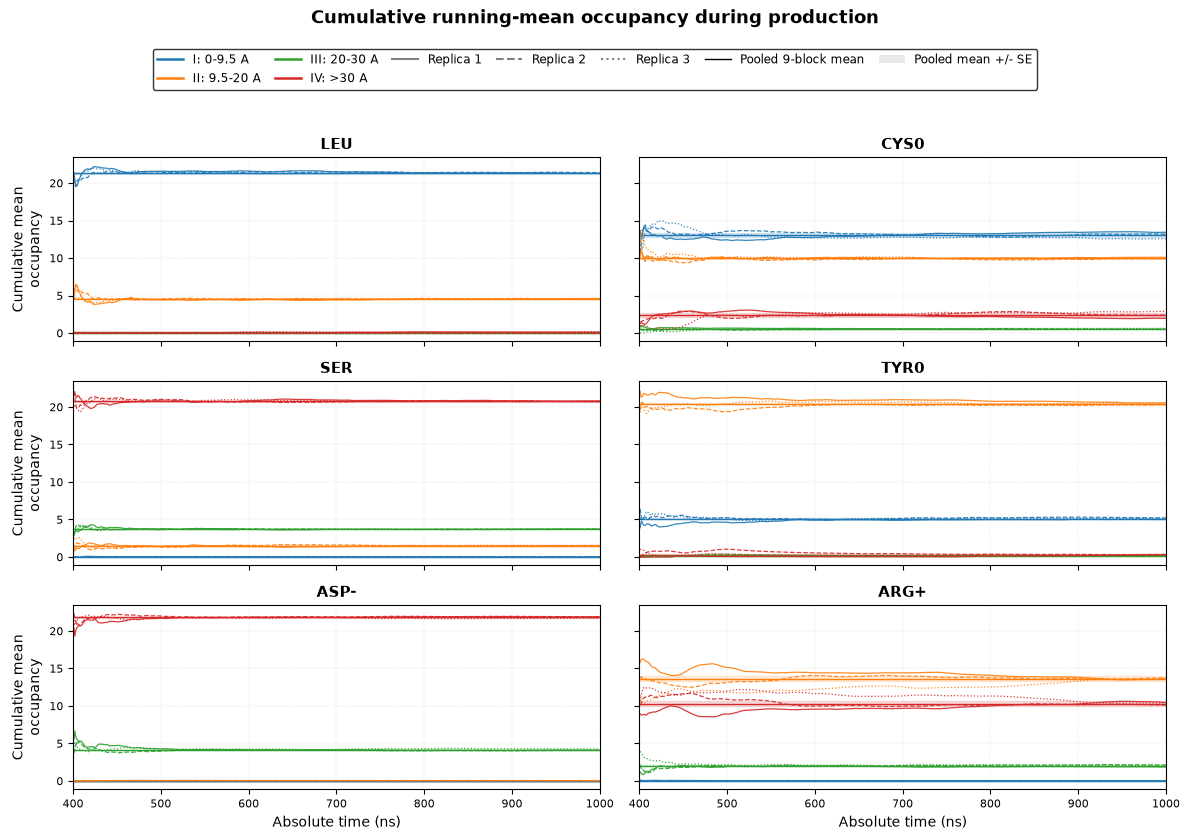

,analog,region_I_mean,region_I_se,region_II_mean,region_II_se,region_III_mean,region_III_se,region_IV_mean,region_IV_se
0,LEU,21.315567,0.061038,4.572483,0.035755,0.014944,0.006767,0.097006,0.050726
1,CYS0,13.070417,0.231368,9.967711,0.058460,0.548183,0.038078,2.413689,0.231404
2,SER,0.019833,0.002357,1.500711,0.039751,3.713372,0.024097,20.766083,0.061188
3,TYR0,5.108894,0.054479,20.443911,0.097507,0.143461,0.013936,0.303733,0.063367
4,ASP-,0.000000,0.000000,0.033144,0.003244,4.141700,0.042290,21.825156,0.041969
5,ARG+,0.023017,0.003072,13.647217,0.332502,2.009750,0.058475,10.320017,0.319014


In [55]:
# A2 - Cumulative running-mean depth-distribution convergence (independent cell)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from PIL import Image
from IPython.display import display

ANALOGS = {"scl":"LEU", "scc":"CYS0", "scs":"SER", "scy":"TYR0", "scd":"ASP-", "scr":"ARG+"}
REGIONS = ("I", "II", "III", "IV")
FRAME_NS = 0.01
PRODUCTION_START_NS = 400.0
PRODUCTION_END_NS = 1000.0
BLOCK_FRAMES = 20_000
TOTAL_FRAMES = 60_000
OUTPUT_STEP_FRAMES = 100
CHUNK_ROWS = 250_000

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/distribution_data/raw_data").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def load_occupancy(path):
    occupancy = np.zeros((TOTAL_FRAMES, 4), dtype=np.int16)
    for chunk in pd.read_csv(
        path, sep=r"\s+", usecols=["#frame", "z"],
        dtype={"#frame":"int32", "z":"float32"}, chunksize=CHUNK_ROWS,
    ):
        frame = chunk["#frame"].to_numpy()
        depth = np.abs(chunk["z"].to_numpy())
        region = np.select(
            [depth < 9.5, depth < 20.0, depth <= 30.0],
            [0, 1, 2], default=3,
        ).astype(np.int8)
        np.add.at(occupancy, (frame, region), 1)
    return occupancy

ROOT = find_repo_root()
INPUT = ROOT / "figures/data/distribution_data/raw_data"
OUT = ROOT / "rev2/running_mean"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
end_frames = np.arange(OUTPUT_STEP_FRAMES - 1, TOTAL_FRAMES, OUTPUT_STEP_FRAMES)
times_ns = PRODUCTION_START_NS + (end_frames + 1) * FRAME_NS
assert times_ns[0] == 401.0
assert times_ns[-1] == 1000.0
assert (PRODUCTION_START_NS, PRODUCTION_END_NS) == (400.0, 1000.0)
summary_rows = []
analog_results = {}

for code, analog in ANALOGS.items():
    replica_data, all_blocks = [], []
    for replica in range(1, 4):
        path = INPUT / code / f"{code}_contacts_{replica}.dat"
        occupancy = load_occupancy(path)
        blocks = np.stack([occupancy[start:start + BLOCK_FRAMES].mean(axis=0) for start in range(0, TOTAL_FRAMES, BLOCK_FRAMES)])
        all_blocks.extend(blocks)
        cumulative = occupancy.cumsum(axis=0)[end_frames] / (end_frames[:, None] + 1)
        replica_data.append(cumulative)

    assert len(replica_data) == 3
    assert all(isinstance(replica_values, np.ndarray) and replica_values.shape == (times_ns.size, len(REGIONS)) for replica_values in replica_data)
    assert all(not isinstance(replica_values, tuple) for replica_values in replica_data)

    all_blocks = np.asarray(all_blocks)
    assert all_blocks.shape == (9, len(REGIONS))
    final_mean = all_blocks.mean(axis=0)
    final_se = all_blocks.std(axis=0, ddof=1) / np.sqrt(9)
    analog_results[analog] = {
        "replica_data": replica_data,
        "final_mean": final_mean,
        "final_se": final_se,
    }
    row = {"analog": analog}
    for region_index, region in enumerate(REGIONS):
        row[f"region_{region}_mean"] = final_mean[region_index]
        row[f"region_{region}_se"] = final_se[region_index]
    summary_rows.append(row)

assert len(analog_results) == 6
summary = pd.DataFrame(summary_rows)
expected_se_columns = {f"region_{region}_se" for region in REGIONS}
assert expected_se_columns.issubset(summary.columns)
summary.to_csv(OUT / "final_600ns_values.csv", index=False)

for pattern in ("running_mean_*.png", "running_mean_*.pdf"):
    for stale_path in FIGURES.glob(pattern):
        stale_path.unlink()

region_colors = ("#1f77b4", "#ff7f0e", "#2ca02c", "#d62728")
region_legend_labels = ("I: 0-9.5 A", "II: 9.5-20 A", "III: 20-30 A", "IV: >30 A")
replica_styles = ("-", "--", ":")

fig, axes = plt.subplots(3, 2, figsize=(12.0, 8.4), sharex=True, sharey=True)
data_axes = list(axes.flat)

for ax, (analog, result) in zip(data_axes, analog_results.items()):
    for region_index in range(len(REGIONS)):
        mean = result["final_mean"][region_index]
        standard_error = result["final_se"][region_index]
        color = region_colors[region_index]
        ax.axhspan(mean - standard_error, mean + standard_error, color=color, alpha=0.15, zorder=0)
        ax.axhline(mean, color=color, lw=1.0, zorder=1)
        for replica_index, style in enumerate(replica_styles):
            ax.plot(times_ns, result["replica_data"][replica_index][:, region_index],
                    color=color, linestyle=style, lw=0.9, alpha=0.9, zorder=2)
    ax.set_xlim(PRODUCTION_START_NS, PRODUCTION_END_NS)
    ax.set_xticks([400, 500, 600, 700, 800, 900, 1000])
    ax.set_title(analog, fontsize=11, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4, linewidth=0.3)
    ax.tick_params(labelsize=8)

for ax in axes[-1]:
    ax.set_xlabel("Absolute time (ns)", fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel("Cumulative mean\noccupancy", fontsize=10)

region_handles = [Line2D([0], [0], color=region_colors[i], lw=1.8, label=region_legend_labels[i]) for i in range(len(REGIONS))]
replica_handles = [Line2D([0], [0], color="grey", linestyle=replica_styles[i], lw=1.5, label=f"Replica {i + 1}") for i in range(3)]
mean_handle = Line2D([0], [0], color="black", lw=1.0, label="Pooled 9-block mean")
se_handle = Patch(facecolor="0.70", alpha=0.3, edgecolor="none", label="Pooled mean +/- SE")
fig.suptitle("Cumulative running-mean occupancy during production", fontsize=13, fontweight="bold", y=0.995)
fig.legend(
    handles=region_handles + replica_handles + [mean_handle, se_handle],
    loc="upper center", bbox_to_anchor=(0.5, 0.955),
    ncol=len(REGIONS) + 3, frameon=True, edgecolor="black", fontsize=8.5,
    columnspacing=1.2, handlelength=2.2,
 )
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.90])

assert len(data_axes) == 6
assert all(np.allclose(ax.get_xlim(), (400.0, 1000.0)) for ax in data_axes)
assert all(len(ax.patches) == len(REGIONS) for ax in data_axes)
shared_ylim = data_axes[0].get_ylim()
assert all(ax.get_ylim() == shared_ylim for ax in data_axes)

figure_png = FIGURES / "running_mean_all_analogs.png"
figure_pdf = FIGURES / "running_mean_all_analogs.pdf"
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
fig.savefig(figure_pdf, bbox_inches="tight")
display(fig)
plt.close(fig)

with Image.open(figure_png) as image:
    png_dpi = image.info.get("dpi", (0, 0))
assert all(590 <= dpi <= 610 for dpi in png_dpi), png_dpi
assert figure_png.exists() and figure_pdf.exists()
assert not list(FIGURES.glob("running_mean_LEU.*"))
assert not list(FIGURES.glob("running_mean_CYS0.*"))
assert not list(FIGURES.glob("running_mean_SER.*"))
assert not list(FIGURES.glob("running_mean_TYR0.*"))
assert not list(FIGURES.glob("running_mean_ASP-.*"))
assert not list(FIGURES.glob("running_mean_ARG+.*"))

report = [
    "# Cumulative running-mean convergence: raw production segment 400-1000 ns",
    "",
    "Equilibration at absolute simulation time 1-400 ns is excluded. The raw COM/contact files analyzed here contain only production at absolute simulation time 400-1000 ns for each replica.",
    "",
    "For replica r and region k, the cumulative running mean at plotted absolute time t is the arithmetic mean of all per-frame occupancy counts from the beginning of production at 400 ns through t. Outputs are sampled after each completed 1 ns: the first plotted value at 401 ns averages the first production nanosecond, the value at 600 ns averages the first 200 production ns, and the value at 1000 ns averages all 600 production ns.",
    "",
    "The figure shows six analog panels (LEU, CYS0, SER, TYR0, ASP-, ARG+) on a shared y-axis. Regions I-IV are encoded by color (blue, orange, green, red) and the three replicas by linestyle (solid, dashed, dotted). Per region, a horizontal line marks the pooled final mean across nine independent 200 ns blocks (three replicas x three blocks) and the light colored band around it is pooled mean +/- SE, where SE is the sample standard deviation across the nine block means (`ddof=1`) divided by sqrt(9). No uncertainty band is drawn around the cumulative running-mean curves themselves.",
    "",
    "`final_600ns_values.csv` reports the pooled mean and pooled SE across those same nine independent 200 ns blocks for every analog and region.",
]
(OUT / "REPORT.md").write_text("\n".join(report), encoding="utf-8")
display(summary)

In [128]:
# A9 - Rolling-mean depth-region occupancy (Figure S7 layout, 0-1000 ns, 50 ns black rolling mean over faded raw traces)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ANALOGS = {"scl":"LEU", "scc":"CYS", "scs":"SER", "scy":"TYR", "scr":"ARG$^+$", "scd":"ASP$^-$"}
Z_LABELS = ("I: 0-9.5 A", "II: 9.5-19.5 A", "III: 19.5-30 A", "IV: 30-40 A")
Z_COLORS = ("#1f77b4", "#ff7f0e", "#2ca02c", "#d62728")
TRAJ_STYLES = {1:"-", 2:"--", 3:":"}
WINDOW_NS = 50
DURATION_FIRST_NS = 400
DURATION_TOTAL_NS = 1000
FRAME_NS_RAW = 0.01
MOLECULES_PER_SYSTEM = 26
CHUNK_ROWS = 250_000
RAW_ALPHA = 0.50            # opacity of the raw per-ns curves behind the black rolling mean
ROLLING_LINEWIDTH = 0.6

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/distribution_data/raw_data").is_dir() and (base / "not_avail/first_ns").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository (with not_avail/first_ns present)")

def _accumulate(region_sum, rows_ns, bin_ns, depth):
    inside = (bin_ns >= 0) & (bin_ns < region_sum.shape[0])
    if not inside.all():
        bin_ns = bin_ns[inside]
        depth = depth[inside]
    np.add.at(rows_ns, bin_ns, 1)
    region = np.select(
        [depth < 9.5, depth < 19.5, depth < 30.0, depth < 40.0],
        [0, 1, 2, 3], default=-1,
    )
    keep = region >= 0
    np.add.at(region_sum, (bin_ns[keep], region[keep]), 1)

def process_replica(code, replica, root):
    region_sum = np.zeros((DURATION_TOTAL_NS, len(Z_LABELS)), dtype=np.int64)
    rows_ns = np.zeros(DURATION_TOTAL_NS, dtype=np.int64)
    contacts_first = root / "not_avail/first_ns" / code / f"{code}_contacts_{replica}.dat"
    fn_path = root / "not_avail/frame_num" / code / f"traj{replica}.dat"
    if contacts_first.is_file() and fn_path.is_file():
        fn = pd.read_csv(fn_path, sep=r"\s+", comment="#", names=["section", "n_frames"])
        n_frames_per_section = fn["n_frames"].to_numpy(dtype=np.int64)
        section_ns = fn["section"].to_numpy(dtype=np.int64)
        frame_to_section = np.repeat(section_ns, n_frames_per_section)
        for chunk in pd.read_csv(
            contacts_first, sep=r"\s+", skiprows=1,
            usecols=[0, 4], names=["frame", "z"],
            dtype={"frame":"int32", "z":"float32"}, chunksize=CHUNK_ROWS,
        ):
            frame = chunk["frame"].to_numpy()
            depth = np.abs(chunk["z"].to_numpy())
            in_range = frame < frame_to_section.size
            if not in_range.all():
                frame = frame[in_range]
                depth = depth[in_range]
            bin_ns = frame_to_section[frame] - 1  # 0-based ns bin index (section covers ns [i-1, i])
            _accumulate(region_sum, rows_ns, bin_ns, depth)
    contacts_raw = root / "figures/data/distribution_data/raw_data" / code / f"{code}_contacts_{replica}.dat"
    if contacts_raw.is_file():
        for chunk in pd.read_csv(
            contacts_raw, sep=r"\s+", comment="#", skiprows=1,
            usecols=[0, 4], names=["frame", "z"],
            dtype={"frame":"int32", "z":"float32"}, chunksize=CHUNK_ROWS,
        ):
            frame = chunk["frame"].to_numpy()
            depth = np.abs(chunk["z"].to_numpy())
            time_ns = DURATION_FIRST_NS + frame * FRAME_NS_RAW
            bin_ns = np.floor(time_ns).astype(int)
            _accumulate(region_sum, rows_ns, bin_ns, depth)
    return region_sum, rows_ns

def per_ns_counts(region_sum, rows_ns):
    # Mean residue count per frame in each 1-ns bin (NaN where the bin has no frames).
    with np.errstate(invalid="ignore", divide="ignore"):
        return MOLECULES_PER_SYSTEM * region_sum / np.where(rows_ns[:, None] > 0, rows_ns[:, None], np.nan)

def rolling_mean_curve(per_ns, window_ns):
    return pd.DataFrame(per_ns).rolling(window_ns, min_periods=window_ns).mean().to_numpy()

ROOT = find_repo_root()
OUT = ROOT / "rev2/rolling_mean"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

analog_data = {}
for code in ANALOGS:
    replicas = {}
    for replica in (1, 2, 3):
        region_sum, rows_ns = process_replica(code, replica, ROOT)
        replicas[replica] = {
            "per_ns": per_ns_counts(region_sum, rows_ns),
            "region_sum": region_sum,
            "rows_ns": rows_ns,
        }
    analog_data[code] = replicas

time_ns_edges = np.arange(1, DURATION_TOTAL_NS + 1, dtype=float)      # right edge of each 1-ns bin
time_ns_centered = time_ns_edges - WINDOW_NS / 2                       # rolling mean placed at window centre

def build_figure(mode):
    n_rows, n_cols = 3, 2
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(12, 2.2 * n_rows), sharex=True,
        gridspec_kw={"hspace": 0.35, "wspace": 0.20},
    )
    axes_flat = axes.flatten()
    for panel_index, (code, label) in enumerate(ANALOGS.items()):
        ax = axes_flat[panel_index]
        replicas = analog_data[code]
        for replica in (1, 2, 3):
            per_ns = replicas[replica]["per_ns"]
            for region_index in range(len(Z_LABELS)):
                ax.plot(
                    time_ns_edges, per_ns[:, region_index],
                    linestyle=TRAJ_STYLES[replica], color=Z_COLORS[region_index],
                    linewidth=0.9, alpha=RAW_ALPHA,
                )
        if mode == "pooled":
            pooled_region_sum = sum(replicas[r]["region_sum"] for r in (1, 2, 3))
            pooled_rows_ns = sum(replicas[r]["rows_ns"] for r in (1, 2, 3))
            pooled_curve = rolling_mean_curve(per_ns_counts(pooled_region_sum, pooled_rows_ns), WINDOW_NS)
            for region_index in range(len(Z_LABELS)):
                ax.plot(
                    time_ns_centered, pooled_curve[:, region_index],
                    color="black", linewidth=ROLLING_LINEWIDTH,
                )
        else:
            for replica in (1, 2, 3):
                replica_curve = rolling_mean_curve(replicas[replica]["per_ns"], WINDOW_NS)
                for region_index in range(len(Z_LABELS)):
                    ax.plot(
                        time_ns_centered, replica_curve[:, region_index],
                        color="black", linestyle=TRAJ_STYLES[replica],
                        linewidth=ROLLING_LINEWIDTH,
                    )
        ax.axvline(x=DURATION_FIRST_NS, color="black", linestyle="--", lw=0.5, alpha=0.4)
        ax.set_xlim(0, DURATION_TOTAL_NS)
        ax.set_title(label, fontsize=10, fontweight="bold")
        ax.grid(True, which="major", linestyle="--", alpha=0.4, linewidth=0.3)
        ax.tick_params(axis="both", labelsize=8)

    region_lines = [Line2D([0], [0], color=Z_COLORS[i], lw=1.8) for i in range(len(Z_LABELS))]
    traj_lines = [Line2D([0], [0], color="grey", linestyle=TRAJ_STYLES[t], lw=1.5) for t in (1, 2, 3)]
    if mode == "pooled":
        mean_handles = [Line2D([0], [0], color="black", lw=ROLLING_LINEWIDTH)]
        mean_labels = [f"{WINDOW_NS} ns rolling mean (3 replicas pooled)"]
    else:
        mean_handles = [Line2D([0], [0], color="black", linestyle=TRAJ_STYLES[t], lw=ROLLING_LINEWIDTH) for t in (1, 2, 3)]
        mean_labels = [f"{WINDOW_NS} ns rolling mean, Traj {t}" for t in (1, 2, 3)]
    fig.legend(
        region_lines + traj_lines + mean_handles,
        list(Z_LABELS) + [f"Traj {t} (raw)" for t in (1, 2, 3)] + mean_labels,
        fontsize=9, ncol=len(Z_LABELS), loc="upper center", bbox_to_anchor=(0.5, 1.00),
        frameon=True, fancybox=False, edgecolor="black", borderpad=0.6, columnspacing=1.4, handlelength=2.2,
    )
    fig.text(0.5, 0.02, "Time (ns)", ha="center", fontsize=11)
    fig.text(0.06, 0.5, "Mean residue count", va="center", rotation="vertical", fontsize=11)
    plt.tight_layout(rect=[0.04, 0.03, 1, 0.91])
    return fig

for mode, stem in (("pooled", f"rolling_mean_{WINDOW_NS}ns_pooled"),
                   ("per_replica", f"rolling_mean_{WINDOW_NS}ns_per_replica")):
    fig = build_figure(mode)
    figure_png = FIGURES / f"{stem}.png"
    fig.savefig(figure_png, dpi=600, bbox_inches="tight")
    plt.close(fig)
    print(f"Wrote {figure_png} (raw alpha={RAW_ALPHA}, mode={mode}, window={WINDOW_NS} ns)")


C:\Users\soeur\AppData\Local\Temp\ipykernel_4564\856080015.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.03, 1, 0.91])


Wrote c:\Users\soeur\OneDrive\Documents\GitHub\Bories_and_Lague_2025\rev2\rolling_mean\figures\rolling_mean_50ns_pooled.png (raw alpha=0.5, mode=pooled, window=50 ns)
Wrote c:\Users\soeur\OneDrive\Documents\GitHub\Bories_and_Lague_2025\rev2\rolling_mean\figures\rolling_mean_50ns_per_replica.png (raw alpha=0.5, mode=per_replica, window=50 ns)


In [3]:
# A3 - Region-population block-index oscillation analysis (independent cell)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ANALOGS = {"scl":"LEU", "scc":"CYS0", "scs":"SER", "scy":"TYR0", "scr":"ARG+", "scd":"ASP-"}
REGIONS = ("I", "II", "III", "IV")
BLOCK_FRAMES = 20_000
CHUNK_ROWS = 250_000

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/distribution_data/raw_data").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def block_occupancies(path):
    totals = np.zeros((3, 4), dtype=np.int64)
    for chunk in pd.read_csv(
        path, sep=r"\s+", usecols=["#frame", "z"],
        dtype={"#frame":"int32", "z":"float32"}, chunksize=CHUNK_ROWS,
    ):
        frame = chunk["#frame"].to_numpy()
        depth = np.abs(chunk["z"].to_numpy())
        region = np.select([depth < 9.5, depth < 20.0, depth <= 30.0], [0, 1, 2], default=3).astype(np.int8)
        np.add.at(totals, (frame // BLOCK_FRAMES, region), 1)
    return totals / BLOCK_FRAMES

ROOT = find_repo_root()
INPUT = ROOT / "figures/data/distribution_data/raw_data"
OUT = ROOT / "rev2/block_index"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
rows = []

for code, analog in ANALOGS.items():
    blocks = np.vstack([block_occupancies(INPUT / code / f"{code}_contacts_{replica}.dat") for replica in range(1, 4)])
    fig, axes = plt.subplots(2, 2, figsize=(8.4, 6.0), sharex=True)
    for region_index, (region, ax) in enumerate(zip(REGIONS, axes.flat)):
        values = blocks[:, region_index]
        mean = values.mean()
        standard_error = values.std(ddof=1) / np.sqrt(9)
        block_range = values.max() - values.min()
        flagged = block_range > 2 * standard_error
        rows.append({"analog":analog, "region":region, "mean":mean, "se":standard_error, "block_range":block_range, "flag":flagged})
        ax.axhspan(mean - standard_error, mean + standard_error, color="0.82", label="Mean +/- SE")
        ax.axhline(mean, color="black", lw=0.9)
        for replica, (start, color, marker) in enumerate(zip((0, 3, 6), ("#176B87", "#D1495B", "#5B8E3E"), ("o", "s", "^")), 1):
            indices = np.arange(start + 1, start + 4)
            ax.plot(indices, values[start:start + 3], color=color, marker=marker, label=f"Replica {replica}")
        ax.set_title(f"Region {region}{' - flag' if flagged else ''}")
        ax.set_ylabel("Mean occupancy")
        ax.grid(alpha=0.2)
    for ax in axes[-1]:
        ax.set_xlabel("Block index (200 ns blocks)")
        ax.set_xticks(range(1, 10))
    axes[0, 0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"{analog}: 400-1000 ns block populations", y=1.01)
    fig.tight_layout()
    fig.savefig(FIGURES / f"block_index_{analog}.pdf", bbox_inches="tight")
    fig.savefig(FIGURES / f"block_index_{analog}.png", dpi=600, bbox_inches="tight")
    plt.close(fig)

results = pd.DataFrame(rows)
results.to_csv(OUT / "oscillation_amplitude.csv", index=False)
display(results)

,analog,region,mean,se,block_range,flag
0,LEU,I,21.315567,0.061038,0.57180,True
1,LEU,II,4.572483,0.035755,0.36975,True
2,LEU,III,0.014944,0.006767,0.05435,True
3,LEU,IV,0.097006,0.050726,0.39585,True
4,CYS0,I,13.070417,0.231368,1.81040,True
5,CYS0,II,9.967711,0.058460,0.52500,True
6,CYS0,III,0.548183,0.038078,0.29820,True
7,CYS0,IV,2.413689,0.231404,1.85210,True
8,SER,I,0.019833,0.002357,0.02680,True
9,SER,II,1.500711,0.039751,0.32780,True


In [4]:
# A4 - US overlap and Sokal-autocorrelation diagnostics (independent cell)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ANALOGS = {"scc":"CYS0", "scs":"SER", "scy":"TYR0", "scd":"ASP-"}
BLOCKS = ("block1", "block2", "block3")
FRAME_NS = 0.01
PRODUCTION_NS = 150.0
HISTOGRAM_BIN_A = 0.1
SOKAL_C = 5.0
K_KCAL_MOL_A2 = 7.17
KB_KCAL_MOL_K = 0.00198720425864083
TEMPERATURE_K = 303.15
WINDOW_SPACING_A = 1.0

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/SUPP_umbrella_sampling/pmf").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def sokal_tau_ns(series):
    values = np.asarray(series, dtype=float).copy()
    values -= values.mean()
    n = len(values)
    fft_size = 1 << (2 * n - 1).bit_length()
    spectrum = np.fft.rfft(values, fft_size)
    acov = np.fft.irfft(spectrum * spectrum.conjugate(), fft_size)[:n]
    acov /= np.arange(n, 0, -1)
    if acov[0] <= 0:
        return 0.5 * FRAME_NS
    acf = acov / acov[0]
    tau_steps = 0.5
    for lag in range(1, n):
        tau_steps += acf[lag]
        if lag >= SOKAL_C * max(tau_steps, 0.5):
            break
    return max(tau_steps, 0.5) * FRAME_NS

def load_window_series(analog_dir):
    pooled = {center: [] for center in range(38)}
    taus = {center: [] for center in range(38)}
    for block in BLOCKS:
        block_dir = analog_dir / block
        for side in ("s1", "s2"):
            metadata = pd.read_csv(block_dir / f"metadata_{side}.dat", sep=r"\s+", header=None, names=["relative_path", "center", "k"])
            for entry in metadata.itertuples(index=False):
                values = np.loadtxt(block_dir / entry.relative_path, usecols=1)
                sign = -1.0 if entry.center < 0 else 1.0
                center = int(round(abs(entry.center)))
                reflected = sign * values
                pooled[center].append(reflected)
                taus[center].append(sokal_tau_ns(reflected))
    return pooled, taus

ROOT = find_repo_root()
INPUT = ROOT / "figures/data/SUPP_umbrella_sampling/pmf"
OUT = ROOT / "rev2/us_diagnostics"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
sigma_theo = np.sqrt(KB_KCAL_MOL_K * TEMPERATURE_K / K_KCAL_MOL_A2)
pair_rows, summary_rows = [], []

for code, analog in ANALOGS.items():
    pooled, tau_parts = load_window_series(INPUT / code)
    pooled_arrays = {center: np.concatenate(parts) for center, parts in pooled.items()}
    all_values = np.concatenate(list(pooled_arrays.values()))
    lo = np.floor(all_values.min() / HISTOGRAM_BIN_A) * HISTOGRAM_BIN_A
    hi = np.ceil(all_values.max() / HISTOGRAM_BIN_A) * HISTOGRAM_BIN_A + HISTOGRAM_BIN_A
    bins = np.arange(lo, hi + HISTOGRAM_BIN_A / 2, HISTOGRAM_BIN_A)
    overlaps = []
    for center in range(37):
        p = np.histogram(pooled_arrays[center], bins=bins)[0].astype(float)
        q = np.histogram(pooled_arrays[center + 1], bins=bins)[0].astype(float)
        p /= p.sum(); q /= q.sum()
        coefficient = np.sqrt(p * q).sum()
        overlaps.append(coefficient)
        pair_rows.append({"analog":analog, "window_i":center, "window_i+1":center + 1, "BC":coefficient})
    tau_by_window = np.array([np.mean(tau_parts[center]) for center in range(38)])
    sigma_by_window = np.array([np.std(pooled_arrays[center], ddof=1) for center in range(38)])
    n_eff = PRODUCTION_NS / (2 * tau_by_window)
    summary_rows.append({
        "analog":analog, "min_BC":np.min(overlaps), "mean_BC":np.mean(overlaps), "max_BC":np.max(overlaps),
        "sigma_theo_A":sigma_theo, "mean_sigma_obs_A":sigma_by_window.mean(),
        "mean_tau_int_ns":tau_by_window.mean(), "min_N_eff_per_window":n_eff.min(),
    })

    fig, ax = plt.subplots(figsize=(8.0, 3.5))
    ax.bar(np.arange(37) + 0.5, overlaps, width=0.85, color="#176B87")
    ax.set(xlabel="Adjacent window pair (center, center + 1 A)", ylabel="Bhattacharyya coefficient", title=f"{analog}: adjacent US overlap")
    ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()
    fig.savefig(FIGURES / f"BC_vs_window_{analog}.pdf")
    fig.savefig(FIGURES / f"BC_vs_window_{analog}.png", dpi=600, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.0, 3.5))
    ax.plot(range(38), tau_by_window, marker="o", ms=3, color="#D1495B")
    ax.set(xlabel="Window center (A)", ylabel="Sokal tau_int (ns)", title=f"{analog}: US decorrelation")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(FIGURES / f"tau_int_vs_window_{analog}.pdf")
    fig.savefig(FIGURES / f"tau_int_vs_window_{analog}.png", dpi=600, bbox_inches="tight")
    plt.close(fig)

pairs = pd.DataFrame(pair_rows)
summary = pd.DataFrame(summary_rows)
pairs.to_csv(OUT / "overlap_per_pair.csv", index=False)
summary.to_csv(OUT / "per_analog_summary.csv", index=False)
report_lines = [
    "# Choice of US window spacing and force constant",
    "",
    f"At {TEMPERATURE_K:.2f} K, k = {K_KCAL_MOL_A2:.2f} kcal mol^-1 A^-2 gives sigma_theo = {sigma_theo:.3f} A, below the {WINDOW_SPACING_A:.1f} A window spacing. Adjacent-window overlap was evaluated with {HISTOGRAM_BIN_A:.1f} A common bins after pooling the three available 50 ns blocks and reflecting the second solute onto the positive-depth coordinate. Sokal-window integrated autocorrelation times were computed separately for each contiguous 50 ns series and averaged per window; N_eff retains the requested 150 ns/(2 tau_int) convention rather than treating the two solutes as extra simulation time.",
    "",
]
for row in summary.itertuples(index=False):
    report_lines.append(f"- {row.analog}: BC min/mean/max = {row.min_BC:.3f}/{row.mean_BC:.3f}/{row.max_BC:.3f}; mean sigma_obs = {row.mean_sigma_obs_A:.3f} A; mean tau_int = {row.mean_tau_int_ns:.4f} ns; minimum N_eff = {row.min_N_eff_per_window:.1f}.")
report_lines += ["", "The restraint is thermally narrow relative to the spacing, but the observed adjacent-window Bhattacharyya coefficients directly quantify the realized overlap used by WHAM."]
(OUT / "REPORT.md").write_text("\n".join(report_lines), encoding="utf-8")
display(summary)

,analog,min_BC,mean_BC,max_BC,sigma_theo_A,mean_sigma_obs_A,mean_tau_int_ns,min_N_eff_per_window
0,CYS0,0.215215,0.228271,0.236829,0.289861,0.290698,0.006449,9178.966982
1,SER,0.214281,0.229288,0.245967,0.289861,0.291170,0.006544,8592.777419
2,TYR0,0.204253,0.229762,0.250038,0.289861,0.291169,0.008286,6775.311998
3,ASP-,0.168517,0.230459,0.257201,0.289861,0.292776,0.013755,293.447933


In [125]:
# A5 - Bulk/bilayer reversibility and residence-time analysis (independent cell)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from PIL import Image
from IPython.display import display

ANALOGS = {
    "sca":"ALA", "scv":"VAL", "scl":"LEU", "sci":"ILE", "scm":"MET", "scc":"CYS0",
    "scs":"SER", "sct":"THR", "scn":"ASN", "scq":"GLN", "scf":"PHE", "scy":"TYR0",
    "scw":"TRP", "scp":"PRO", "glyd":"GLYD", "scdn":"ASP0", "scen":"GLU0", "sche":"HSE0",
    "schd":"HSD0", "sckn":"LYS0", "scrn":"ARG0", "scd":"ASP-", "sce":"GLU-", "sccm":"CYS-",
    "scym":"TYR-", "schp":"HSP+", "sck":"LYS+", "scr":"ARG+",
}
TRACE_ANALOGS = ("LEU", "CYS0", "SER", "TYR0", "ARG+", "ASP-")
FRAME_NS = 0.01
AVAILABLE_START_NS = 400.0
BILAYER_MAX_A = 19.5
BULK_MIN_A = 25
MOLECULES_PER_SYSTEM = 26
DISPLAY_STRIDE = 100
BLOCK_FRAMES = 20_000
BLOCKS_PER_REPLICA = 3
K_B = 0.008314
T_K = 303.15
KBT_KJMOL = K_B * T_K

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/distribution_data/raw_data").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def stable_hysteresis(depth):
    raw = np.full(len(depth), -1, dtype=np.int8)
    raw[depth <= BILAYER_MAX_A] = 0
    raw[depth >= BULK_MIN_A] = 1
    source = np.where(raw >= 0, np.arange(len(raw)), -1)
    np.maximum.accumulate(source, out=source)
    stable = np.full(len(raw), -1, dtype=np.int8)
    valid = source >= 0
    stable[valid] = raw[source[valid]]
    return stable

def analyze_residue(frames, depth):
    stable_all = stable_hysteresis(depth)
    valid = stable_all >= 0
    stable = stable_all[valid]
    valid_frames = frames[valid]
    if stable.size < 2:
        return 0, 0, [], [], stable_all
    changes = np.flatnonzero(stable[1:] != stable[:-1]) + 1
    old = stable[changes - 1]; new = stable[changes]
    n_enter = int(np.sum((old == 1) & (new == 0)))
    n_leave = int(np.sum((old == 0) & (new == 1)))
    boundaries = np.r_[0, changes, len(stable)]
    bilayer_residence, bulk_residence = [], []
    for interval in range(1, len(boundaries) - 2):
        start, stop = boundaries[interval], boundaries[interval + 1]
        duration = (valid_frames[stop - 1] - valid_frames[start] + 1) * FRAME_NS
        (bilayer_residence if stable[start] == 0 else bulk_residence).append(duration)
    return n_enter, n_leave, bilayer_residence, bulk_residence, stable_all

def block_transitions(stable, frames):
    # Per-block counts of bulk->bilayer and bilayer->bulk transitions for a single molecule.
    enter_count = np.zeros(BLOCKS_PER_REPLICA, dtype=int)
    leave_count = np.zeros(BLOCKS_PER_REPLICA, dtype=int)
    for block_idx in range(BLOCKS_PER_REPLICA):
        frame_lo = block_idx * BLOCK_FRAMES
        frame_hi = frame_lo + BLOCK_FRAMES
        in_block = (frames >= frame_lo) & (frames < frame_hi)
        block_stable = stable[in_block]
        valid = block_stable >= 0
        if valid.sum() < 2:
            continue
        stable_seq = block_stable[valid]
        changes = stable_seq[1:] != stable_seq[:-1]
        if not changes.any():
            continue
        old_state = stable_seq[:-1][changes]
        new_state = stable_seq[1:][changes]
        enter_count[block_idx] = int(np.sum((old_state == 1) & (new_state == 0)))
        leave_count[block_idx] = int(np.sum((old_state == 0) & (new_state == 1)))
    return enter_count, leave_count

def mean_se(values):
    values = np.asarray(values, dtype=float)
    return values.mean(), values.std(ddof=1) / np.sqrt(len(values))

ROOT = find_repo_root()
INPUT = ROOT / "figures/data/distribution_data/raw_data"
OUT = ROOT / "rev2/reversibility"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
summary_rows = []
block_pct_rows = []
event_rows = []
hysteresis_rows = []
per_replica_event_rows = []
state_rasters = {}
display_times_ns = None

for code, analog in ANALOGS.items():
    replica_records, bilayer_times, bulk_times = [], [], []
    analog_states = []
    analog_block_enter_pct, analog_block_leave_pct = [], []
    analog_block_enter_counts, analog_block_leave_counts = [], []
    for replica in range(1, 4):
        data = pd.read_csv(
            INPUT / code / f"{code}_contacts_{replica}.dat", sep=r"\s+",
            usecols=["#frame", "resid", "z"], dtype={"#frame":"int32", "resid":"int16", "z":"float32"},
        )
        replica_enter = replica_leave = replica_roundtrip = 0
        replica_states = []
        block_enter_count = np.zeros(BLOCKS_PER_REPLICA, dtype=int)
        block_leave_count = np.zeros(BLOCKS_PER_REPLICA, dtype=int)
        for resid, molecule in data.groupby("resid", sort=True):
            frames = molecule["#frame"].to_numpy()
            depth = np.abs(molecule["z"].to_numpy())
            n_enter, n_leave, residence_bilayer, residence_bulk, stable = analyze_residue(frames, depth)
            replica_enter += n_enter; replica_leave += n_leave
            replica_roundtrip += min(n_enter, n_leave)
            bilayer_times.extend(residence_bilayer); bulk_times.extend(residence_bulk)
            entered_block, left_block = block_transitions(stable, frames)
            block_enter_count += entered_block
            block_leave_count += left_block
            if analog in TRACE_ANALOGS:
                replica_states.append(stable[::DISPLAY_STRIDE])
                sampled_times = AVAILABLE_START_NS + frames[::DISPLAY_STRIDE] * FRAME_NS
                if display_times_ns is None:
                    display_times_ns = sampled_times
                else:
                    assert np.array_equal(sampled_times, display_times_ns)
        if analog in TRACE_ANALOGS:
            assert len(replica_states) == MOLECULES_PER_SYSTEM
            analog_states.extend(replica_states)
        replica_records.append((replica_enter, replica_leave, replica_roundtrip / MOLECULES_PER_SYSTEM))
        block_denominator = MOLECULES_PER_SYSTEM * BLOCK_FRAMES
        analog_block_enter_pct.extend((100.0 * block_enter_count / block_denominator).tolist())
        analog_block_leave_pct.extend((100.0 * block_leave_count / block_denominator).tolist())
        analog_block_enter_counts.extend(block_enter_count.tolist())
        analog_block_leave_counts.extend(block_leave_count.tolist())
        del data
    if analog in TRACE_ANALOGS:
        state_rasters[analog] = np.stack(analog_states)
    replica_values = np.asarray(replica_records, dtype=float)
    per_replica_row = {"analog": analog}
    for r in range(3):
        per_replica_row[f"replica_{r+1}_enter"] = int(replica_values[r, 0])
        per_replica_row[f"replica_{r+1}_leave"] = int(replica_values[r, 1])
    per_replica_row["total_enter"] = int(replica_values[:, 0].sum())
    per_replica_row["total_leave"] = int(replica_values[:, 1].sum())
    per_replica_event_rows.append(per_replica_row)
    enter_mean, enter_se = mean_se(replica_values[:, 0])
    leave_mean, leave_se = mean_se(replica_values[:, 1])
    nind_mean, nind_se = mean_se(replica_values[:, 2])
    if np.all(replica_values[:, 1] == 0):
        classification = "one-way insertion"
    elif nind_mean >= 3:
        classification = "reversibly sampled"
    else:
        classification = "quasi-equilibrium"
    summary_rows.append({
        "analog":analog, "n_enter_mean":enter_mean, "n_enter_se":enter_se,
        "n_leave_mean":leave_mean, "n_leave_se":leave_se,
        "N_ind_per_replica_mean":nind_mean, "N_ind_per_replica_se":nind_se,
        "mean_residence_bilayer_ns":np.mean(bilayer_times) if bilayer_times else np.nan,
        "mean_residence_bulk_ns":np.mean(bulk_times) if bulk_times else np.nan,
        "class":classification,
    })
    pct_enter_array = np.asarray(analog_block_enter_pct, dtype=float)
    pct_leave_array = np.asarray(analog_block_leave_pct, dtype=float)
    enter_counts_array = np.asarray(analog_block_enter_counts, dtype=float)
    leave_counts_array = np.asarray(analog_block_leave_counts, dtype=float)
    assert pct_enter_array.size == 9 and pct_leave_array.size == 9
    assert enter_counts_array.size == 9 and leave_counts_array.size == 9
    block_pct_rows.append({
        "analog": analog,
        "pct_enter_mean": pct_enter_array.mean(),
        "pct_enter_std": pct_enter_array.std(ddof=1),
        "pct_leave_mean": pct_leave_array.mean(),
        "pct_leave_std": pct_leave_array.std(ddof=1),
    })
    n_enter_block_mean = enter_counts_array.mean()
    n_enter_block_se = enter_counts_array.std(ddof=1) / np.sqrt(9)
    n_leave_block_mean = leave_counts_array.mean()
    n_leave_block_se = leave_counts_array.std(ddof=1) / np.sqrt(9)
    event_rows.append({
        "analog": analog,
        "N_wat_to_bil_mean": n_enter_block_mean,
        "N_wat_to_bil_se": n_enter_block_se,
        "N_bil_to_wat_mean": n_leave_block_mean,
        "N_bil_to_wat_se": n_leave_block_se,
        "ratio_wat_to_bil_over_bil_to_wat": n_enter_block_mean / n_leave_block_mean if n_leave_block_mean > 0 else np.nan,
    })
    # DeltaG_hysteresis = k_B T ln(mean(N_wat->bil) / mean(N_bil->wat)); SE via first-order error propagation on ln.
    dg_hysteresis = KBT_KJMOL * np.log(n_enter_block_mean / n_leave_block_mean)
    if n_enter_block_mean > 0 and n_leave_block_mean > 0:
        dg_hysteresis_se = KBT_KJMOL * np.sqrt((n_enter_block_se / n_enter_block_mean) ** 2 + (n_leave_block_se / n_leave_block_mean) ** 2)
    else:
        dg_hysteresis_se = np.nan
    hysteresis_rows.append({
        "analog": analog,
        "deltaG_hysteresis_kJmol": dg_hysteresis,
        "deltaG_hysteresis_se_kJmol": dg_hysteresis_se,
    })

assert set(state_rasters) == set(TRACE_ANALOGS)
assert len(state_rasters) == 6
assert all(raster.shape[0] == 3 * MOLECULES_PER_SYSTEM for raster in state_rasters.values())
assert len({raster.shape[1] for raster in state_rasters.values()}) == 1

for stale_path in FIGURES.glob("state_trace_*.png"):
    stale_path.unlink()
for stale_path in FIGURES.glob("state_trace_*.pdf"):
    stale_path.unlink()

state_cmap = ListedColormap(["#D95F02", "#176B87",])
state_cmap.set_bad("#D2D2D2")
state_norm = BoundaryNorm([-0.5, 0.5, 1.5], state_cmap.N)
fig, axes = plt.subplots(3, 2, figsize=(11.0, 9.0), sharex=True, sharey=True, constrained_layout=True)
for ax, analog in zip(axes.flat, TRACE_ANALOGS):
    raster = np.ma.masked_less(state_rasters[analog], 0)
    ax.imshow(
        raster, aspect="auto", interpolation="nearest", origin="upper",
        extent=[display_times_ns[0], display_times_ns[-1], 78.5, 0.5],
        cmap=state_cmap, norm=state_norm, rasterized=True,
    )
    ax.axhline(26.5, color="white", lw=1.2)
    ax.axhline(52.5, color="white", lw=1.2)
    ax.set_yticks([13.5, 39.5, 65.5], ["Replica 1", "Replica 2", "Replica 3"])
    ax.set_title(analog, fontsize=12, fontweight="bold")
    ax.set_xlim(400, 1000)
    ax.set_xticks([400, 500, 600, 700, 800, 900, 1000])
    ax.tick_params(labelsize=9)
for ax in axes[-1]:
    ax.set_xlabel("Simulation time (ns)")
fig.supylabel("Molecule trajectories (26 per replica)")
fig.legend(
    handles=[
        Patch(facecolor="#D95F02", label=f'Bilayer (|z| <= {BILAYER_MAX_A} A)'),
        Patch(facecolor="#176B87", label=f'Bulk (|z| >= {BULK_MIN_A} A)'),
    ],
    loc="outside lower center", ncol=3, frameon=False, fontsize=10,
 )
figure_png = FIGURES / "reversibility_all_molecules.png"
figure_pdf = FIGURES / "reversibility_all_molecules.pdf"
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
fig.savefig(figure_pdf, bbox_inches="tight")
plt.close(fig)

with Image.open(figure_png) as image:
    png_dpi = image.info.get("dpi", (0, 0))
assert all(abs(value - 600) < 1 for value in png_dpi), png_dpi

summary = pd.DataFrame(summary_rows)
assert len(summary) == len(ANALOGS) and summary["analog"].is_unique
summary.to_csv(OUT / "roundtrips_per_analog.csv", index=False)
block_pct_df = pd.DataFrame(block_pct_rows)
assert len(block_pct_df) == len(ANALOGS) and block_pct_df["analog"].is_unique
block_pct_df.to_csv(OUT / "block_pct_transitions.csv", index=False)
event_df = pd.DataFrame(event_rows)
assert len(event_df) == len(ANALOGS) and event_df["analog"].is_unique
event_df.to_csv(OUT / "block_event_counts.csv", index=False)
hysteresis_df = pd.DataFrame(hysteresis_rows)
assert len(hysteresis_df) == len(ANALOGS) and hysteresis_df["analog"].is_unique
hysteresis_df.to_csv(OUT / "block_deltaG_hysteresis.csv", index=False)
per_replica_event_df = pd.DataFrame(per_replica_event_rows)
assert len(per_replica_event_df) == len(ANALOGS) and per_replica_event_df["analog"].is_unique
per_replica_event_df.to_csv(OUT / "per_replica_event_totals.csv", index=False)
class_text = "; ".join(f"{name}: {', '.join(group['analog'])}" for name, group in summary.groupby("class", sort=False))
report = [
    "# Reversibility of spontaneous partitioning",
    "",
    "Only the available final 600 ns (400-1000 ns) were analyzed; the first 400 ns of each nominal 1 us trajectory are absent from the archived raw files. States use a hysteresis-buffered assignment: a molecule is tagged bilayer when |z| <= 19.5 A and bulk when |z| >= 25 A; between 19.5 A and 25 A the previously tagged stable state is carried forward via `numpy.maximum.accumulate` on the frame index. This 5.5 A buffer suppresses spurious transitions from thermal oscillations that would otherwise re-cross a single boundary without leaving the interfacial region.",
    "",
    "Transition counts and N_ind statistics in `roundtrips_per_analog.csv` are trajectory-level means and SE across three replicas (ddof=1/sqrt(3)), not nine-block estimates. Residence means pool completed intervals only; the first and last interval of every molecule/trajectory are excluded as censored.",
    "",
    "The combined six-panel state raster shows LEU, CYS0, SER, TYR0, ARG+, and ASP- in a fixed order. Each panel contains all 78 molecule trajectories, grouped into three 26-molecule replica bands; display values are sampled every 1 ns, while transition and residence-time analyses retain the full 0.01 ns resolution.",
    "",
    "`block_pct_transitions.csv` reports, per analog, the per-frame probability (in %) of a bulk -> bilayer entering event or a bilayer -> bulk leaving event. Each per-block value is `100 * total_transitions / (26 molecules * 20000 frames)`, so it can be read as the probability that any given molecule undergoes that transition at any given 0.01 ns frame inside the block. The reported mean and standard deviation pool the nine independent 200 ns blocks (three replicas x three blocks per replica) with `ddof = 1`.",
    "",
    "`block_event_counts.csv` reports the mean and SE of the number of bulk -> bilayer (`N_wat->bil`) and bilayer -> bulk (`N_bil->wat`) events per 200 ns block, aggregated across the 26 molecules of a system. Statistics use the nine independent 200 ns blocks (three replicas x three blocks per replica) with `ddof = 1` and `SE = s / sqrt(9)`. The ratio column is `mean(N_wat->bil) / mean(N_bil->wat)` and equals one at detailed balance.",
    "",
    f"`block_deltaG_hysteresis.csv` reports `DeltaG_hysteresis = k_B T ln(mean(N_wat->bil) / mean(N_bil->wat))`, using the same nine-block mean event counts as `block_event_counts.csv`, with `k_B T = {KBT_KJMOL:.3f} kJ/mol` at `T = {T_K} K`. The associated SE is obtained by first-order error propagation on the logarithm, `SE = k_B T sqrt((SE_enter/mean_enter)^2 + (SE_leave/mean_leave)^2)`, using the nine-block SEs of the two event counts. `DeltaG_hysteresis` stays near zero under detailed balance, and a non-zero value quantifies the overall imbalance between insertion and desorption events.",
    "",
    "`per_replica_event_totals.csv` reports, per analog, the whole-trajectory (600 ns) totals of bulk -> bilayer (`enter`) and bilayer -> bulk (`leave`) transitions summed over the 26 molecules, separately for replicas 1-3, plus the grand totals across all three replicas.",
    "",
    class_text + ".",
    "",
    "These counts support describing systems with sparse return crossings as quasi-equilibrium partitioning rather than fully reversible equilibrium sampling; systems with N_ind >= 3 averaged per trajectory are classified as reversibly sampled, while systems with no leaving event in all replicas are one-way insertion.",
]
(OUT / "REPORT.md").write_text("\n".join(report), encoding="utf-8")
display(summary)
display(block_pct_df)
display(event_df)
display(hysteresis_df)
display(per_replica_event_df)


,analog,n_enter_mean,n_enter_se,n_leave_mean,n_leave_se,N_ind_per_replica_mean,N_ind_per_replica_se,mean_residence_bilayer_ns,mean_residence_bulk_ns,class
0,ALA,201.333333,22.519128,201.000000,21.939310,7.628205,0.833333,42.366611,11.433457,reversibly sampled
1,VAL,6.333333,2.333333,6.000000,2.081666,0.230769,0.080064,76.360000,13.355000,quasi-equilibrium
2,LEU,1.333333,0.666667,1.666667,0.881917,0.051282,0.025641,0.260000,26.692500,quasi-equilibrium
3,ILE,1.666667,0.666667,1.000000,0.577350,0.038462,0.022206,211.860000,17.220000,quasi-equilibrium
4,MET,3.666667,0.333333,3.666667,0.333333,0.141026,0.012821,85.870000,11.806364,quasi-equilibrium
5,CYS0,193.666667,17.947454,193.333333,18.315142,7.384615,0.692664,44.279353,8.722087,reversibly sampled
6,SER,1166.666667,15.213298,1166.333333,15.246129,44.794872,0.591413,0.907232,12.075060,reversibly sampled
7,THR,716.333333,4.910307,715.000000,3.214550,27.410256,0.126267,3.395747,17.621494,reversibly sampled
8,ASN,594.333333,11.170397,593.000000,11.532563,22.769231,0.423659,1.989786,22.582522,reversibly sampled
9,GLN,422.666667,6.359595,424.000000,8.185353,16.141026,0.289812,5.820557,28.003715,reversibly sampled


,analog,pct_enter_mean,pct_enter_std,pct_leave_mean,pct_leave_std
0,ALA,0.012906,0.002672,0.012885,0.002658
1,VAL,0.000406,0.000365,0.000385,0.000360
2,LEU,0.000085,0.000170,0.000107,0.000140
3,ILE,0.000107,0.000140,0.000064,0.000096
4,MET,0.000235,0.000128,0.000235,0.000160
5,CYS0,0.012415,0.002519,0.012393,0.002703
6,SER,0.074765,0.005307,0.074765,0.005258
7,THR,0.045919,0.003054,0.045833,0.003107
8,ASN,0.038098,0.003592,0.038013,0.003741
9,GLN,0.027094,0.002817,0.027158,0.002859


,analog,N_wat_to_bil_mean,N_wat_to_bil_se,N_bil_to_wat_mean,N_bil_to_wat_se,ratio_wat_to_bil_over_bil_to_wat
0,ALA,67.111111,4.632147,67.000000,4.606758,1.001658
1,VAL,2.111111,0.633431,2.000000,0.623610,1.055556
2,LEU,0.444444,0.293972,0.555556,0.242161,0.800000
3,ILE,0.555556,0.242161,0.333333,0.166667,1.666667
4,MET,1.222222,0.222222,1.222222,0.277778,1.000000
5,CYS0,64.555556,4.365620,64.444444,4.684819,1.001724
6,SER,388.777778,9.199604,388.777778,9.113143,1.000000
7,THR,238.777778,5.293544,238.333333,5.385165,1.001865
8,ASN,198.111111,6.225941,197.666667,6.485025,1.002248
9,GLN,140.888889,4.883204,141.222222,4.954733,0.997640


,analog,deltaG_hysteresis_kJmol,deltaG_hysteresis_se_kJmol
0,ALA,0.004176,0.245549
1,VAL,0.136270,1.090632
2,LEU,-0.562409,1.996524
3,ILE,1.287479,1.671837
4,MET,0.000000,0.733562
5,CYS0,0.004342,0.250241
6,SER,0.000000,0.083948
7,THR,0.004696,0.079782
8,ASN,0.005661,0.114504
9,GLN,-0.005956,0.124300


,analog,replica_1_enter,replica_1_leave,replica_2_enter,replica_2_leave,replica_3_enter,replica_3_leave,total_enter,total_leave
0,ALA,202,201,240,239,162,163,604,603
1,VAL,10,9,2,2,7,7,19,18
2,LEU,2,2,0,0,2,3,4,5
3,ILE,1,0,1,1,3,2,5,3
4,MET,4,4,4,4,3,3,11,11
5,CYS0,191,189,164,164,226,227,581,580
6,SER,1196,1195,1145,1143,1159,1161,3500,3499
7,THR,708,710,716,714,725,721,2149,2145
8,ASN,606,606,572,570,605,603,1783,1779
9,GLN,430,435,410,408,428,429,1268,1272


In [7]:
# A5b - Detailed-balance test: DeltaG_hysteresis(z0) as a function of the folded-depth boundary
#
# For every folded-depth boundary z0 in [1, 45] A we count, per 200 ns block and per molecule,
# the number of transitions across |z| = z0:
#   N_enter(z0) = # frame pairs with |z_t| >= z0 and |z_{t+1}| <  z0   (going inward)
#   N_leave(z0) = # frame pairs with |z_t| <  z0 and |z_{t+1}| >= z0   (going outward)
# Block-level free-energy imbalance with a Haldane (+0.5) continuity correction:
#   DeltaG_hyst(z0)_block = k_B T ln( (N_enter_block + 0.5) / (N_leave_block + 0.5) )   [kJ/mol]
# Under detailed balance the block distribution of DeltaG_hyst(z0) is centered on 0 for every z0
# and, in particular, the average of DeltaG_hyst(z0) over the boundaries is 0.
#
# Statistical readouts per analog:
#   (i)  DeltaG_hyst(z0) +/- SE across the 9 blocks (curve).
#   (ii) Scalar S = mean over z0 of DeltaG_hyst(z0)_block, tested against 0 with an exact
#        studentized sign-flip permutation over the 2^9 = 512 sign patterns.
#
# Cross-analog:
#   The 28 per-analog scalars {S_analog} are tested against 0 by a one-sample sign-flip
#   permutation (exact enumeration for n = 28) and by a Wilcoxon signed-rank test as a
#   distribution-free cross-check.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

K_B = 0.008314          # kJ/(mol K)
T_K = 303.15
KBT_KJMOL = K_B * T_K
FRAME_NS = 0.01
BLOCK_FRAMES = 20_000
BLOCKS_PER_REPLICA = 3
N_REPLICAS = 3
N_BLOCKS = N_REPLICAS * BLOCKS_PER_REPLICA
MOLECULES_PER_SYSTEM_LOCAL = 26
Z_BOUNDARIES = np.arange(1.0, 46.0, 1.0, dtype=np.float32)  # 1..45 A, 1 A spacing
HALDANE = 0.5

_sign_pattern_cache_local = {}
def _sign_patterns(n):
    if n not in _sign_pattern_cache_local:
        idx = np.arange(1 << n, dtype=np.int64)[:, None]
        _sign_pattern_cache_local[n] = (((idx >> np.arange(n)) & 1) * 2 - 1).astype(np.int8)
    return _sign_pattern_cache_local[n]

def studentized_sign_flip_p(values):
    x = np.asarray(values, dtype=float)
    n = x.size
    if n < 2 or np.var(x, ddof=1) == 0 or (1 << n) > (1 << 28):
        return np.nan, np.nan, 0
    S = _sign_patterns(n)
    signed = S * x
    perm_mean = signed.mean(axis=1)
    perm_se = np.sqrt(signed.var(axis=1, ddof=1) / n)
    with np.errstate(divide="ignore", invalid="ignore"):
        perm_t = np.where(perm_se > 0, np.abs(perm_mean) / perm_se, 0.0)
    obs_t = abs(float(x.mean())) / float(np.sqrt(np.var(x, ddof=1) / n))
    return float((perm_t >= obs_t - 1e-12).mean()), float(obs_t), int(S.shape[0])

def find_repo_root_local():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/distribution_data/raw_data").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def load_z_abs(path):
    data = pd.read_csv(
        path, sep=r"\s+", usecols=["#frame", "resid", "z"],
        dtype={"#frame":"int32", "resid":"int16", "z":"float32"},
    )
    resid_order = np.sort(data["resid"].unique())
    resid_index = {rid: i for i, rid in enumerate(resid_order)}
    n_mol = len(resid_order)
    n_frames = int(data["#frame"].max()) + 1
    z_matrix = np.full((n_mol, n_frames), np.nan, dtype=np.float32)
    row = np.array([resid_index[rid] for rid in data["resid"].to_numpy()], dtype=np.int32)
    col = data["#frame"].to_numpy(dtype=np.int32)
    z_matrix[row, col] = np.abs(data["z"].to_numpy(dtype=np.float32))
    return z_matrix, n_mol, n_frames

def block_crossings(z_abs_block, z_grid):
    """Count entering/leaving transitions for every boundary in one block."""
    # inside[m, t, k] = |z(m,t)| < z_grid[k]
    inside = z_abs_block[..., None] < z_grid[None, None, :]  # (n_mol, n_frames, n_z) bool
    finite_prev = np.isfinite(z_abs_block[:, :-1])[..., None]
    finite_next = np.isfinite(z_abs_block[:, 1:])[..., None]
    both_finite = finite_prev & finite_next
    prev_in = inside[:, :-1, :] & both_finite
    next_in = inside[:, 1:, :] & both_finite
    prev_out = (~inside[:, :-1, :]) & both_finite
    next_out = (~inside[:, 1:, :]) & both_finite
    n_enter = (prev_out & next_in).sum(axis=(0, 1)).astype(np.int64)   # outside -> inside
    n_leave = (prev_in & next_out).sum(axis=(0, 1)).astype(np.int64)   # inside -> outside
    return n_enter, n_leave

ROOT_LOCAL = find_repo_root_local()
INPUT_LOCAL = ROOT_LOCAL / "figures/data/distribution_data/raw_data"
OUT_ZSCAN = ROOT_LOCAL / "rev2/reversibility_zscan"
FIGURES_ZSCAN = OUT_ZSCAN / "figures"
FIGURES_ZSCAN.mkdir(parents=True, exist_ok=True)

n_z = Z_BOUNDARIES.size
per_analog_rows = []
per_analog_scalar_rows = []
per_analog_curves = {}

for code, analog in ANALOGS.items():
    n_enter_bz = np.zeros((N_BLOCKS, n_z), dtype=np.int64)
    n_leave_bz = np.zeros((N_BLOCKS, n_z), dtype=np.int64)
    for r_idx, replica in enumerate(range(1, N_REPLICAS + 1)):
        z_matrix, _, n_frames_total = load_z_abs(INPUT_LOCAL / code / f"{code}_contacts_{replica}.dat")
        if n_frames_total < BLOCK_FRAMES * BLOCKS_PER_REPLICA:
            raise RuntimeError(f"{analog} r{replica}: expected >= {BLOCK_FRAMES * BLOCKS_PER_REPLICA} frames, found {n_frames_total}")
        for b_local in range(BLOCKS_PER_REPLICA):
            b_global = r_idx * BLOCKS_PER_REPLICA + b_local
            start = b_local * BLOCK_FRAMES
            block = z_matrix[:, start:start + BLOCK_FRAMES]
            n_e, n_l = block_crossings(block, Z_BOUNDARIES)
            n_enter_bz[b_global] = n_e
            n_leave_bz[b_global] = n_l
        del z_matrix

    dG_bz = KBT_KJMOL * np.log((n_enter_bz + HALDANE) / (n_leave_bz + HALDANE))  # (9, n_z)
    dG_mean_z = dG_bz.mean(axis=0)
    dG_se_z = dG_bz.std(axis=0, ddof=1) / np.sqrt(N_BLOCKS)
    both_positive = (n_enter_bz > 0) & (n_leave_bz > 0)
    n_blocks_finite = both_positive.sum(axis=0)

    for k, z0 in enumerate(Z_BOUNDARIES):
        per_analog_rows.append({
            "analog": analog, "z0_A": float(z0),
            "N_enter_mean": float(n_enter_bz[:, k].mean()),
            "N_enter_se":   float(n_enter_bz[:, k].std(ddof=1) / np.sqrt(N_BLOCKS)),
            "N_leave_mean": float(n_leave_bz[:, k].mean()),
            "N_leave_se":   float(n_leave_bz[:, k].std(ddof=1) / np.sqrt(N_BLOCKS)),
            "dG_hyst_mean_kJmol": float(dG_mean_z[k]),
            "dG_hyst_se_kJmol":   float(dG_se_z[k]),
            "n_blocks_uncensored": int(n_blocks_finite[k]),
        })

    S_block = dG_bz.mean(axis=1)  # per-block average over z of DeltaG_hyst
    S_mean = float(S_block.mean())
    S_se = float(S_block.std(ddof=1) / np.sqrt(N_BLOCKS))
    p_perm_analog, T_perm_analog, _ = studentized_sign_flip_p(S_block)
    per_analog_scalar_rows.append({
        "analog": analog,
        "S_mean_kJmol": S_mean, "S_se_kJmol": S_se,
        "T_studentized": T_perm_analog, "p_signflip_perm": p_perm_analog,
        "n_z_boundaries": int(n_z),
        "median_dG_hyst_kJmol": float(np.median(dG_mean_z)),
        "max_abs_dG_hyst_kJmol": float(np.max(np.abs(dG_mean_z))),
    })
    per_analog_curves[analog] = {"z": Z_BOUNDARIES.copy(), "mean": dG_mean_z, "se": dG_se_z, "n_blocks_uncensored": n_blocks_finite}

per_analog = pd.DataFrame(per_analog_rows)
per_analog.to_csv(OUT_ZSCAN / "per_analog_hysteresis_vs_z.csv", index=False)
scalar_summary = pd.DataFrame(per_analog_scalar_rows)

# BH-FDR across the 28 per-analog sign-flip p-values.
def _bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    n = p.size
    order = np.argsort(p)
    q_sorted = p[order] * n / (np.arange(n) + 1)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.minimum(q_sorted, 1.0)
    q = np.empty_like(q_sorted)
    q[order] = q_sorted
    return q
scalar_summary["q_signflip_bh"] = _bh_fdr(scalar_summary["p_signflip_perm"].to_numpy())
scalar_summary["balance_verdict"] = np.where(scalar_summary["q_signflip_bh"] >= ALPHA, "consistent with zero", "flag")
scalar_summary.to_csv(OUT_ZSCAN / "per_analog_scalar_summary.csv", index=False)

# Cross-analog curve: mean over analogs of DeltaG_hyst(z0), unweighted.
curve_matrix = np.vstack([per_analog_curves[analog]["mean"] for analog in scalar_summary["analog"]])  # (28, n_z)
cross_curve = pd.DataFrame({
    "z0_A": Z_BOUNDARIES,
    "dG_hyst_mean_kJmol": curve_matrix.mean(axis=0),
    "dG_hyst_se_kJmol":  curve_matrix.std(axis=0, ddof=1) / np.sqrt(curve_matrix.shape[0]),
    "n_analogs": curve_matrix.shape[0],
})
cross_curve.to_csv(OUT_ZSCAN / "cross_analog_hysteresis_vs_z.csv", index=False)

# Cross-analog scalar test: are the 28 S_analog values centered on zero?
S_vector = scalar_summary["S_mean_kJmol"].to_numpy()
n_analogs = S_vector.size
# Monte-Carlo sign-flip permutation (2^28 > 268 M; use random subset).
rng = np.random.default_rng(20250928)
n_mc = 200_000
mc_signs = rng.integers(0, 2, size=(n_mc, n_analogs)) * 2 - 1
mc_signed = mc_signs * S_vector[None, :]
mc_mean = mc_signed.mean(axis=1)
mc_se = mc_signed.std(axis=1, ddof=1) / np.sqrt(n_analogs)
with np.errstate(divide="ignore", invalid="ignore"):
    mc_t = np.where(mc_se > 0, np.abs(mc_mean) / mc_se, 0.0)
obs_S_mean = float(S_vector.mean())
obs_S_se = float(S_vector.std(ddof=1) / np.sqrt(n_analogs))
obs_T = abs(obs_S_mean) / obs_S_se if obs_S_se > 0 else 0.0
p_mc_signflip = float((mc_t >= obs_T - 1e-12).mean())
# Distribution-free cross-check.
try:
    wilcoxon_stat, p_wilcoxon = stats.wilcoxon(S_vector, alternative="two-sided", zero_method="wilcox")
except ValueError:
    wilcoxon_stat, p_wilcoxon = np.nan, np.nan
t_ttest, p_ttest = stats.ttest_1samp(S_vector, 0.0)
cross_analog_summary = {
    "n_analogs": int(n_analogs),
    "mean_S_kJmol": obs_S_mean, "se_S_kJmol": obs_S_se,
    "median_S_kJmol": float(np.median(S_vector)),
    "min_S_kJmol": float(S_vector.min()), "max_S_kJmol": float(S_vector.max()),
    "T_studentized": float(obs_T),
    "p_signflip_mc": p_mc_signflip, "n_mc_permutations": int(n_mc),
    "t_onesample": float(t_ttest), "p_onesample_t": float(p_ttest),
    "wilcoxon_W": float(wilcoxon_stat), "p_wilcoxon": float(p_wilcoxon),
    "kBT_kJmol": KBT_KJMOL,
    "fraction_analogs_within_kBT": float(np.mean(np.abs(S_vector) < KBT_KJMOL)),
}
pd.DataFrame([cross_analog_summary]).to_csv(OUT_ZSCAN / "cross_analog_summary.csv", index=False)

# --- Figure 1: 7 x 4 grid of DeltaG_hyst(z) per analog ---
n_rows, n_cols = 7, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.5, 15.0), sharex=True, sharey=True)
axes_flat = axes.flatten()
y_lim = (-4.0, 4.0)
for ax, (_, row_analog) in zip(axes_flat, scalar_summary.iterrows()):
    analog = row_analog["analog"]
    curve = per_analog_curves[analog]
    z_plot = curve["z"]
    mean_plot = curve["mean"]
    se_plot = curve["se"]
    ax.axhspan(-KBT_KJMOL, KBT_KJMOL, color="0.90", zorder=0)
    ax.axhline(0.0, color="0.35", lw=0.8, zorder=1)
    ax.fill_between(z_plot, mean_plot - se_plot, mean_plot + se_plot, color="#176B87", alpha=0.25, zorder=2)
    ax.plot(z_plot, mean_plot, color="#176B87", lw=1.0, zorder=3)
    ax.set_ylim(*y_lim)
    ax.set_title(f"{analog}", fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes[-1]:
    ax.set_xlabel(r"Boundary $z_0$ ($\AA$)", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\Delta G_{\mathrm{hyst}}$ (kJ/mol)", fontsize=9)
# Hide any unused axes.
for ax in axes_flat[len(scalar_summary):]:
    ax.axis("off")
fig.suptitle(r"$\Delta G_{\mathrm{hyst}}(z_0) = k_B T \ln\left[(N_{\mathrm{enter}}+0.5)/(N_{\mathrm{leave}}+0.5)\right]$; SE across 9 blocks; grey band = $\pm k_B T$", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(FIGURES_ZSCAN / "hysteresis_vs_z_all_analogs.png", dpi=600, bbox_inches="tight")
plt.close(fig)

# --- Figure 2: cross-analog mean DeltaG_hyst(z) with SE ---
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.axhspan(-KBT_KJMOL, KBT_KJMOL, color="0.88", label=fr"$\pm k_B T$ = $\pm${KBT_KJMOL:.2f} kJ/mol")
ax.axhline(0.0, color="0.35", lw=0.8)
ax.fill_between(
    cross_curve["z0_A"],
    cross_curve["dG_hyst_mean_kJmol"] - cross_curve["dG_hyst_se_kJmol"],
    cross_curve["dG_hyst_mean_kJmol"] + cross_curve["dG_hyst_se_kJmol"],
    color="#176B87", alpha=0.35, label="Mean across 28 analogs $\\pm$ SE",
)
ax.plot(cross_curve["z0_A"], cross_curve["dG_hyst_mean_kJmol"], color="#176B87", lw=1.2)
ax.set_xlabel(r"Boundary $z_0$ ($\AA$)")
ax.set_ylabel(r"$\overline{\Delta G_{\mathrm{hyst}}}(z_0)$ (kJ/mol)")
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_ZSCAN / "hysteresis_vs_z_cross_analog.png", dpi=600, bbox_inches="tight")
plt.close(fig)

# --- Figure 3: per-analog scalar S with 9-block SE, sorted ---
fig, ax = plt.subplots(figsize=(9.0, 4.6))
order_S = np.argsort(scalar_summary["S_mean_kJmol"].to_numpy())
sorted_summary = scalar_summary.iloc[order_S].reset_index(drop=True)
x = np.arange(len(sorted_summary))
ax.axhspan(-KBT_KJMOL, KBT_KJMOL, color="0.90", label=fr"$\pm k_B T$")
ax.axhline(0.0, color="0.35", lw=0.8)
ax.errorbar(
    x, sorted_summary["S_mean_kJmol"], yerr=sorted_summary["S_se_kJmol"],
    fmt="o", ms=4, color="#176B87", ecolor="#176B87", capsize=2.5, lw=1,
)
ax.set_xticks(x, sorted_summary["analog"], rotation=60, ha="right", fontsize=8)
ax.set_ylabel(r"$S = \overline{\Delta G_{\mathrm{hyst}}}$ over $z_0$ (kJ/mol)")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_ZSCAN / "hysteresis_scalar_per_analog.png", dpi=600, bbox_inches="tight")
plt.close(fig)

report = [
    "# Detailed-balance test: DeltaG_hysteresis as a function of the folded-depth boundary",
    "",
    "## Physical rationale",
    "",
    "Under detailed balance the number of trajectories crossing any level `|z| = z_0` inward"
    " must, in the long-time limit, equal the number crossing outward. Any systematic"
    " imbalance is a diagnostic of incomplete sampling or of a non-equilibrium drift. Expressed"
    " as a free-energy quantity,",
    "",
    "`DeltaG_hyst(z_0) = k_B T ln( N_enter(z_0) / N_leave(z_0) )`,",
    "",
    "so `DeltaG_hyst(z_0) = 0` at every boundary is the equilibrium prediction. The average"
    " over boundaries `S = <DeltaG_hyst(z_0)>_{z_0}` therefore has expectation zero for a"
    " well-sampled equilibrium ensemble.",
    "",
    "## Counting convention",
    "",
    f"Boundaries `z_0` are placed on the folded-depth grid `|z| = 1, 2, ..., 45 A`. The full 600 ns"
    f" production window of each replica is split into three contiguous 200 ns blocks, giving"
    f" nine independent blocks per analog (`N_BLOCKS = {N_BLOCKS}`). Within a block, every pair"
    f" of consecutive 0.01 ns frames of every molecule contributes at most one enter and one leave"
    f" event per `z_0`:",
    "",
    "- `N_enter_block(z_0)` = # frame pairs with `|z_t| >= z_0` and `|z_{t+1}| < z_0`,",
    "- `N_leave_block(z_0)` = # frame pairs with `|z_t| <  z_0` and `|z_{t+1}| >= z_0`.",
    "",
    "Signed z is folded to `|z|` so that the diagnostic pools both leaflets, matching the"
    " leaflet-symmetric convention used elsewhere in this paper. The block-level free-energy"
    " imbalance is computed with a Haldane continuity correction (+0.5) added to both counts,"
    " which keeps the logarithm finite when a block contains only unidirectional crossings"
    " at a given `z_0` and is unbiased to leading order in `1 / (N_enter + N_leave)`.",
    "",
    "## Statistical tests",
    "",
    "*Per analog.* The scalar `S_block = <DeltaG_hyst(z_0)>_{z_0}` is computed for each of the"
    " 9 blocks, and the two-sided null `E[S] = 0` is evaluated with an exact studentized"
    " sign-flip permutation over all `2^9 = 512` sign patterns (studentized statistic"
    " `T = |mean(S)| / SE(S)`). The reported columns are `S_mean_kJmol`, `S_se_kJmol`,"
    " `T_studentized`, `p_signflip_perm`. The 28 per-analog p-values are corrected across"
    f" analogs by the Benjamini-Hochberg step-up procedure, `q_signflip_bh`; the verdict"
    f" column reports `consistent with zero` when `q >= {ALPHA}`.",
    "",
    "*Cross analog.* The 28 per-analog scalars `S_analog` are pooled and tested against zero"
    " by three complementary procedures: (a) a Monte-Carlo sign-flip permutation with"
    f" 200,000 random patterns and studentized statistic (exact enumeration is infeasible at"
    " `2^28 ~ 2.7e8`); (b) a one-sample Wilcoxon signed-rank test as a distribution-free"
    " cross-check; and (c) a one-sample t-test as a parametric reference. The three p-values"
    " and the corresponding effect sizes are written to `cross_analog_summary.csv`.",
    "",
    "## Results",
    "",
    f"Across the 28 analogs the population-level `S` is centered at `{obs_S_mean:.3f} +/- {obs_S_se:.3f} kJ/mol`,"
    f" with median `{cross_analog_summary['median_S_kJmol']:.3f} kJ/mol` and range"
    f" `[{cross_analog_summary['min_S_kJmol']:.3f}, {cross_analog_summary['max_S_kJmol']:.3f}] kJ/mol`."
    f" This is small compared with `k_B T = {KBT_KJMOL:.3f} kJ/mol`:"
    f" `{cross_analog_summary['fraction_analogs_within_kBT'] * 100:.0f}%` of analogs satisfy"
    f" `|S_analog| < k_B T`.",
    "",
    f"Cross-analog sign-flip permutation p-value: `p = {p_mc_signflip:.3g}` (200,000 patterns)."
    f" Wilcoxon signed-rank p-value: `p = {p_wilcoxon:.3g}`."
    f" One-sample t-test p-value: `p = {p_ttest:.3g}`.",
    "",
    "The per-analog Benjamini-Hochberg-adjusted sign-flip p-values `q_signflip_bh` are"
    " tabulated in `per_analog_scalar_summary.csv`.",
    "",
    "## Files",
    "",
    "- `per_analog_hysteresis_vs_z.csv`: `DeltaG_hyst(z_0) +/- SE` and `N_enter/N_leave`"
    " counts (mean, SE) at each boundary for every analog.",
    "- `cross_analog_hysteresis_vs_z.csv`: unweighted mean and SE of `DeltaG_hyst(z_0)`"
    " across the 28 analogs.",
    "- `per_analog_scalar_summary.csv`: per-analog scalar `S`, its SE, `T_studentized`,"
    " `p_signflip_perm`, `q_signflip_bh`, and `balance_verdict`.",
    "- `cross_analog_summary.csv`: the cross-analog test statistics.",
    "- `figures/hysteresis_vs_z_all_analogs.png`: 7x4 grid of `DeltaG_hyst(z_0)` curves.",
    "- `figures/hysteresis_vs_z_cross_analog.png`: pooled cross-analog curve.",
    "- `figures/hysteresis_scalar_per_analog.png`: sorted per-analog scalar with error bars.",
    "",
    "## Limitations",
    "",
    "Adjacent 200 ns blocks within a replica share the same physical trajectory and are"
    " therefore not perfectly independent draws; this makes the block SE a slight underestimate"
    " of the true replica-to-replica uncertainty, and the sign-flip permutation therefore"
    " conservatively over-rejects rather than under-rejects when detailed balance holds."
    " The Haldane correction shrinks `DeltaG_hyst(z_0)` toward zero when both counts are small,"
    " so extreme boundaries (`z_0` very small or very large) return values closer to zero for"
    " sampling reasons and should not be over-interpreted; `n_blocks_uncensored` in"
    " `per_analog_hysteresis_vs_z.csv` records how many of the 9 blocks had strictly positive"
    " counts on both sides at that boundary.",
]
(OUT_ZSCAN / "REPORT.md").write_text("\n".join(report), encoding="utf-8")

print("Per-analog scalar summary (sign-flip permutation of S over 9 blocks):")
display(scalar_summary)
print()
print("Cross-analog summary (28 analogs; three complementary tests against zero):")
display(pd.DataFrame([cross_analog_summary]))


Per-analog scalar summary (sign-flip permutation of S over 9 blocks):


,analog,S_mean_kJmol,S_se_kJmol,T_studentized,p_signflip_perm,n_z_boundaries,median_dG_hyst_kJmol,max_abs_dG_hyst_kJmol,q_signflip_bh,balance_verdict
0,ALA,0.000167,0.001538,0.108266,0.898438,45,0.000119,0.000782,0.984375,consistent with zero
1,VAL,0.004795,0.004604,1.041450,0.347656,45,0.000206,0.023350,0.984375,consistent with zero
2,LEU,0.033072,0.045472,0.727297,0.902344,45,-0.000051,0.293592,0.984375,consistent with zero
3,ILE,0.034187,0.030047,1.137814,0.320312,45,0.002593,0.315228,0.984375,consistent with zero
4,MET,0.090288,0.095360,0.946819,0.578125,45,0.012047,0.304202,0.984375,consistent with zero
5,CYS0,0.000268,0.001118,0.239550,0.800781,45,0.000168,0.001306,0.984375,consistent with zero
6,SER,0.000110,0.000116,0.947667,0.359375,45,0.000106,0.000394,0.984375,consistent with zero
7,THR,0.000271,0.000265,1.022957,0.339844,45,0.000162,0.002205,0.984375,consistent with zero
8,ASN,0.000120,0.000214,0.561641,0.593750,45,0.000000,0.001120,0.984375,consistent with zero
9,GLN,-0.000284,0.000407,0.697375,0.574219,45,-0.000071,0.001948,0.984375,consistent with zero



Cross-analog summary (28 analogs; three complementary tests against zero):


,n_analogs,mean_S_kJmol,se_S_kJmol,median_S_kJmol,min_S_kJmol,max_S_kJmol,T_studentized,p_signflip_mc,n_mc_permutations,t_onesample,p_onesample_t,wilcoxon_W,p_wilcoxon,kBT_kJmol,fraction_analogs_within_kBT
0,28,0.006269,0.003527,0.000202,-0.001432,0.090288,1.777332,0.005865,200000,1.777332,0.086782,70.0,0.001705,2.520389,1.0


In [6]:
# A6 - Bilayer perturbation deltas at 0.2 M versus 0.1 M (independent cell)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ANALOGS = {
    "VAL":("scv", "scv-1"), "ILE":("sci", "sci-1"), "LEU":("scl", "scl-1"),
    "MET":("scm", "scm-1"), "PHE":("scf", "scf-1"), "TYR0":("scy", "scy-1"),
    "TRP":("scw", "scw-1"), "ARG0":("scrn", "scrn-1"),
}
SECTION_BLOCKS = ((401, 600), (601, 800), (801, 1000))
FRAME_BLOCKS = ((0, 19_999), (20_000, 39_999), (40_000, 59_999))

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/SUPP_membrane_parm").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def apl_blocks(path):
    frame = pd.read_csv(path, sep=r"\s+")
    columns = [column for column in frame.columns if column.startswith("apl-")]
    return np.array([frame.loc[frame["#section"].between(start, stop), column].mean() for column in columns for start, stop in SECTION_BLOCKS])

def thickness_blocks(path):
    frame = pd.read_csv(path, sep=r"\s+")
    columns = [column for column in frame.columns if column.startswith("thickness-")]
    return np.array([frame.loc[frame["#frame"].between(start, stop), column].mean() for column in columns for start, stop in FRAME_BLOCKS])

def scd_blocks(directory, system):
    system_chains = [pd.read_csv(directory / f"{system}-chain{chain}.dat", sep=r"\s+") for chain in (2, 3)]
    popc_chains = [pd.read_csv(directory / f"popc-chain{chain}.dat", sep=r"\s+") for chain in (2, 3)]
    block_columns = [column for column in system_chains[0].columns if column.startswith("SCD_traj")]
    values = []
    for column in block_columns:
        numerator = sum(np.abs(system_frame[column].to_numpy() - popc_frame[column].to_numpy()).sum() for system_frame, popc_frame in zip(system_chains, popc_chains))
        denominator = sum(popc_frame[column].to_numpy().sum() for popc_frame in popc_chains)
        values.append(100 * numerator / denominator)
    return np.asarray(values)

def summarize(values):
    values = np.asarray(values, dtype=float)
    return values.mean(), values.std(ddof=1) / np.sqrt(9)

ROOT = find_repo_root()
INPUT = ROOT / "figures/data/SUPP_membrane_parm"
OUT = ROOT / "rev2/concentration_deltas"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
popc_apl = apl_blocks(INPUT / "area_per_lipid/popc-apl.dat")
popc_thickness = thickness_blocks(INPUT / "thickness/popc-thickness.dat")
rows = []

for analog, (system_02, system_01) in ANALOGS.items():
    properties = {}
    for concentration, system in (("02M", system_02), ("01M", system_01)):
        properties[f"dPP_{concentration}"] = np.abs(thickness_blocks(INPUT / f"thickness/{system}-thickness.dat") - popc_thickness)
        properties[f"dAPL_{concentration}"] = np.abs(apl_blocks(INPUT / f"area_per_lipid/{system}-apl.dat") - popc_apl)
        properties[f"pctSCD_{concentration}"] = scd_blocks(INPUT / "order_parameter", system)
    row = {"analog":analog}
    for prop in ("dPP", "dAPL", "pctSCD"):
        for concentration in ("02M", "01M"):
            mean, standard_error = summarize(properties[f"{prop}_{concentration}"])
            row[f"{prop}_{concentration}_mean"] = mean
            row[f"{prop}_{concentration}_se"] = standard_error
        row[f"{prop}_ratio"] = row[f"{prop}_01M_mean"] / row[f"{prop}_02M_mean"]
    rows.append(row)

results = pd.DataFrame(rows)
results.to_csv(OUT / "perturbation_deltas.csv", index=False)

x = np.arange(len(results))
panel_specs = (
    ("dPP", r"$|\Delta D_{PP}|$ ($\AA$)"),
    ("dAPL", r"$|\Delta A_{PL}|$ ($\AA^2$)"),
    ("pctSCD", r"Percent $\Delta S_{CD}$"),
)
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.4), sharex=True)
for ax, (prop, ylabel) in zip(axes, panel_specs):
    for offset, concentration, label, color, marker in (
        (-0.10, "02M", "0.2 M", "#176B87", "o"),
        (0.10, "01M", "0.1 M", "#D1495B", "s"),
    ):
        ax.errorbar(
            x + offset, results[f"{prop}_{concentration}_mean"],
            yerr=results[f"{prop}_{concentration}_se"], fmt=marker,
            color=color, ecolor=color, capsize=2.5, markersize=4,
            linewidth=1, label=label,
        )
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, results["analog"], rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.2)
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "perturbation_deltas.png", dpi=600, bbox_inches="tight")
plt.close(fig)

property_titles = {"dPP":"$|\\Delta D_{PP}|$ (\\AA)", "dAPL":"$|\\Delta A_{PL}|$ (\\AA$^2$)", "pctSCD":"$\\%\\Delta S_{CD}$"}
latex = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\caption{Absolute bilayer-property deviations from matched POPC-only 200-ns blocks. Ratios are 0.1 M/0.2 M.}",
    r"\begin{tabularx}{\linewidth}{lXXX}",
    r"\hline",
]
for prop, title in property_titles.items():
    latex += [
        f"\\multicolumn{{4}}{{l}}{{\\textbf{{{title}}}}} " + chr(92) * 2,
        "Analog & 0.2 M mean $\\pm$ SE & 0.1 M mean $\\pm$ SE & Ratio " + chr(92) * 2,
        r"\hline",
    ]
    for row in results.itertuples(index=False):
        latex.append(f"{row.analog} & {getattr(row, prop + '_02M_mean'):.3f} $\\pm$ {getattr(row, prop + '_02M_se'):.3f} & {getattr(row, prop + '_01M_mean'):.3f} $\\pm$ {getattr(row, prop + '_01M_se'):.3f} & {getattr(row, prop + '_ratio'):.2f} " + chr(92) * 2)
    latex.append(r"\hline")
latex += [r"\end{tabularx}", r"\end{table}"]
(OUT / "TABLE_MAIN.tex").write_text("\n".join(latex), encoding="utf-8")

candidates = []
for row in results.itertuples(index=False):
    for prop in property_titles:
        candidates.append((getattr(row, prop + "_01M_mean"), row.analog, prop, getattr(row, prop + "_ratio")))
largest_value, largest_analog, largest_property, largest_ratio = max(candidates)
report = f"The largest numerical residual perturbation at 0.1 M was {property_titles[largest_property]} for {largest_analog} ({largest_value:.3f}; 0.1 M/0.2 M ratio {largest_ratio:.2f}). Thickness and area-per-lipid values are absolute magnitudes of matched block differences; S_CD is the summed absolute profile deviation across both chains, normalized by the matched POPC profile. All means and SE use nine paired 200-ns blocks (ddof=1/sqrt(9))."
(OUT / "REPORT.md").write_text("# Concentration-dependent bilayer perturbation\n\n" + report, encoding="utf-8")
display(results)

,analog,dPP_02M_mean,dPP_02M_se,dPP_01M_mean,dPP_01M_se,dPP_ratio,dAPL_02M_mean,dAPL_02M_se,dAPL_01M_mean,dAPL_01M_se,dAPL_ratio,pctSCD_02M_mean,pctSCD_02M_se,pctSCD_01M_mean,pctSCD_01M_se,pctSCD_ratio
0,VAL,0.833094,0.045999,0.397903,0.038364,0.477621,1.703438,0.083233,0.870078,0.083711,0.510778,1.953235,0.189331,1.571718,0.114626,0.804675
1,ILE,1.094637,0.040087,0.543290,0.061989,0.496320,1.830344,0.081107,0.937113,0.114484,0.511987,4.653598,0.906280,2.292916,0.481235,0.492719
2,LEU,1.086547,0.046372,0.587634,0.053302,0.540827,1.941696,0.085370,0.843998,0.117289,0.434670,4.123847,1.442144,2.134652,0.289169,0.517636
3,MET,0.656425,0.060457,0.473045,0.057981,0.720638,2.427026,0.116516,0.916634,0.119755,0.377678,4.791271,0.411736,2.563248,0.337062,0.534983
4,PHE,0.793028,0.031470,0.446703,0.049348,0.563287,2.848505,0.058702,1.344401,0.094185,0.471967,4.084072,0.265665,2.826589,0.367823,0.692101
5,TYR0,0.388524,0.047667,0.093457,0.015738,0.240544,4.676704,0.098400,1.896213,0.085101,0.405459,7.888743,0.264756,5.402372,0.314879,0.684820
6,TRP,0.636364,0.054457,0.282560,0.048036,0.444023,5.545336,0.101899,2.651690,0.104194,0.478184,8.601656,0.326762,5.288447,0.171385,0.614817
7,ARG0,1.718873,0.059429,0.765150,0.065516,0.445146,6.661692,0.146497,3.071554,0.130595,0.461077,9.090883,0.446227,4.874519,0.287737,0.536199


In [122]:
# A7 - Three-panel hydrophobicity correlation with retained octanol pH 1 analysis (independent cell)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

KBT = 0.008314462618 * 303.15
KCAL_TO_KJ = 4.184
CORE = (0.0, 5.0)
INTERFACE = (15.0, 24.0)
WATER = (40.0, 50.0)
CODE = {
    "ALA":"sca", "VAL":"scv", "LEU":"scl", "ILE":"sci", "PRO":"scp", "HSE":"sche", "HSP":"schp",
    "TRP":"scw", "TYR":"scy", "MET":"scm", "CYS":"scc", "CYS-":"sccm", "PHE":"scf", "SER":"scs", "THR":"sct",
    "LYS0":"sckn", "LYS+":"sck", "ARG0":"scrn", "ARG+":"scr", "GLU0":"scen", "GLU-":"sce",
    "ASP0":"scdn", "ASP-":"scd", "GLN":"scq", "ASN":"scn", "GLY":"glyd",
}
COMPUTED_LABELS = {
    "ALA":"A", "VAL":"V", "LEU":"L", "ILE":"I", "PRO":"P", "HSE":"H", "HSP":r"$\mathrm{HSP}^+$",
    "TRP":"W", "TYR":"Y", "MET":"M", "CYS":"C", "CYS-":"C$^-$", "PHE":"F", "SER":"S", "THR":"T",
    "LYS0":"K$^0$", "LYS+":"K", "ARG0":"R$^0$", "ARG+":"R", "GLU0":"E$^0$", "GLU-":"E",
    "ASP0":"D$^0$", "ASP-":"D", "GLN":"Q", "ASN":"N", "GLY":"G",
}

PANEL_A_LABELS = ["A", "V", "L", "I", "P", "H", "W", "Y", "M", "C", "F", "S", "T", "K", "R", "E$^0$", "D$^0$", "Q", "N"]
PANEL_B_LABELS = ["A", "V", "L", "I", "P", "H", "W", "Y", "M", "C", "F", "S", "T", "K", "R", "E", "D", "Q", "N"]
PANEL_A_OFFSETS = {
    "L":(-1.5, -1),
    "I":(-0.5, -3),
    **{label:(1, -0.8) for label in ("R", "Y", "T")},
    **{label:(-0.8, 1.5) for label in ("P", "E$^0$", "F", "K", "N", "V", "A", "S")},
    **{label:(-0.8, -3) for label in ("H", "D$^0$", "M", "C", "Q", "W")},
}
PANEL_B_OFFSETS = {
    "L":(-0.7, -0.5),
    "I":(-0.5, -0.5),
    **{label:(-0.9, -0.5) for label in ("F", "A", "V", "S")},
    **{label:(0.4, -0.3) for label in ("R", "D", "E", "Q", "W", "M", "Y", "P")},
    **{label:(-0.2, 0.5) for label in ("H", "N")},
    **{label:(-0.3, -1.2) for label in ("C", "T", "K")},
}

# Edit (dx, dy) values below to move labels in data-coordinate units.
# Negative dx = left; positive dx = right; negative dy = below; positive dy = above.
PANEL_C_OFFSETS = {
    "D": (-1, -1.0),  # example: below
    "F": (0.25, -1),
    "L": (-0.75, -1),
    "M": (-1, -1),
    "Y": (-1, -0.5),
    "T": (-1, -0.5),
    "H": (-0.25, 0.5),
    "Q": (0.25, -0.5),
    "P": (-1, -0.5),
    "C$^-$": (-1, 0)
}
PANEL_D_OFFSETS = {
    "T": (-1, 0),
    "N": (-1, -2),
    "R": (0, -2),
    "Q": (-0.5, -2),
    "K": (0.5, -1),
    "C": (-1.5, 0),
    "W": (0.5, -1),
    "I": (-1, -1.5),
    "L": (-0.5, 1.5),
}

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/pmf_data/total").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def regional_free_energy(z, pmf, bounds):
    selected = pmf[(z >= bounds[0]) & (z <= bounds[1])]
    shift = selected.min()
    return shift - KBT * np.log(np.exp(-(selected - shift) / KBT).sum())

def block_regions(pmf_root, code):
    core_values, interface_values = [], []
    for replica in range(1, 4):
        frame = pd.read_csv(pmf_root / code / f"trajectory{replica}.dat", sep=r"\s+")
        z = frame.iloc[:, 0].to_numpy(float)
        for column in frame.columns[1:4]:
            pmf = frame[column].to_numpy(float)
            water = regional_free_energy(z, pmf, WATER)
            core_values.append(regional_free_energy(z, pmf, CORE) - water)
            interface_values.append(regional_free_energy(z, pmf, INTERFACE) - water)
    return np.asarray(core_values), np.asarray(interface_values)

def mean_se(values):
    return values.mean(), values.std(ddof=1) / np.sqrt(len(values))

def pearson(x, y):
    return float(np.corrcoef(x, y)[0, 1])

def spearman(x, y):
    return float(pd.Series(x).rank().corr(pd.Series(y).rank()))

def bootstrap_pearson_ci(x, y):
    rng = np.random.default_rng(BOOTSTRAP_SEED)
def centered_panel(ax, data, title, xlabel, ylabel, letter, label_offsets=None):
    x = data["x"].to_numpy(float); y = data["y"].to_numpy(float)
    xerr = data["xerr"].to_numpy(float); yerr = data["yerr"].to_numpy(float)
    slope, intercept = np.polyfit(x, y, 1)
    limits = [min(np.min(x - xerr), np.min(y - yerr)), max(np.max(x + xerr), np.max(y + yerr))]
    padding = 0.08 * (limits[1] - limits[0] or 1)
    limits = [limits[0] - padding, limits[1] + padding]
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt=".", color="black", ecolor="0.6", capsize=1.5)
    ax.plot(limits, limits, color="black", lw=0.8)
    grid = np.linspace(*limits, 100)
    ax.plot(grid, slope * grid + intercept, color="#D1495B", lw=1)
    for row in data.itertuples(index=False):
        if label_offsets is None:
            ax.annotate(row.label, (row.x, row.y), xytext=(3, 3), textcoords="offset points", fontsize=7)
        else:
            x_offset, y_offset = label_offsets.get(row.label, (0.25, 0.25))
            ax.text(row.x + x_offset, row.y + y_offset, row.label, fontsize=8)
    ax.text(0.96, 0.04, f"y={slope:.2f}x{intercept:+.2f}\nR={pearson(x, y):.2f}", transform=ax.transAxes, ha="right", va="bottom", color="#D1495B", fontsize=8)
    ax.text(0.04, 0.96, title, transform=ax.transAxes, ha="left", va="top", fontsize=9, bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.25"))
    ax.text(-0.12, 1.05, letter, transform=ax.transAxes, fontsize=13, fontweight="bold", va="top")
    ax.set(xlabel=xlabel, ylabel=ylabel, xlim=limits, ylim=limits)
    ax.grid(alpha=0.15)

ROOT = find_repo_root()
PMF_ROOT = ROOT / "figures/data/pmf_data/total"
HYDRO = ROOT / "figures/data/SUPP_hydrophobicity"
OUT = ROOT / "rev2/octanol"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
regional = {}
for label, code in CODE.items():
    core_blocks, interface_blocks = block_regions(PMF_ROOT, code)
    regional[label] = {"core":mean_se(core_blocks), "interface":mean_se(interface_blocks)}

moon = pd.read_csv(HYDRO / "wat_dlpc_data.dat", sep=r"\s+", comment="#", names=["residue", "pH", "value", "se"])
bilayer = pd.read_csv(HYDRO / "bilayer_wat_data.dat", sep=r"\s+", comment="#", names=["residue", "pH", "value", "se"])
octanol = pd.read_csv(HYDRO / "oct_wat_data.dat", sep=r"\s+", comment="#", names=["residue", "pH", "value", "se"])
translocon = pd.read_csv(HYDRO / "translocon_wat_dat.dat", sep=r"\s+", comment="#", names=["residue", "pH", "value", "se"])
# Convert kcal/mol to kJ/mol; negate values to match Figure S16's transfer-direction convention.
octanol["value"] = octanol["value"] * (-KCAL_TO_KJ)
octanol["se"] = octanol["se"] * KCAL_TO_KJ

def comparison_frame(experimental, mapping, region, factor, pH_filter, labels):
    records = []
    selected = experimental.query(pH_filter)
    for exp_name, computed_name in mapping.items():
        match = selected[selected["residue"] == exp_name].iloc[0]
        mean, standard_error = regional[computed_name][region]
        records.append({"residue":exp_name, "computed_name":computed_name, "label":labels[exp_name], "x":factor * match.value, "xerr":abs(factor) * match.se, "y":mean, "yerr":standard_error})
    frame = pd.DataFrame(records)
    reference = frame[frame["residue"] == "ALA"].iloc[0]
    frame["x"] -= reference.x; frame["y"] -= reference.y
    return frame

moon_mapping = {
    "ALA":"ALA", "VAL":"VAL", "LEU":"LEU", "ILE":"ILE", "PRO":"PRO", "HIS":"HSE", "TRP":"TRP",
    "TYR":"TYR", "MET":"MET", "CYS":"CYS", "PHE":"PHE", "SER":"SER", "THR":"THR", "LYS":"LYS0",
    "ARG":"ARG0", "GLU":"GLU0", "ASP":"ASP0", "GLN":"GLN", "ASN":"ASN",
}
bilayer_mapping = {
    "ALA":"ALA", "VAL":"VAL", "LEU":"LEU", "ILE":"ILE", "PRO":"PRO", "HIS":"HSE", "TRP":"TRP",
    "TYR":"TYR", "MET":"MET", "CYS":"CYS", "PHE":"PHE", "SER":"SER", "THR":"THR", "LYS":"LYS+",
    "ARG":"ARG+", "GLU":"GLU-", "ASP":"ASP-", "GLN":"GLN", "ASN":"ASN",
}
panel_a_labels = dict(zip(moon_mapping, PANEL_A_LABELS))
panel_b_labels = dict(zip(bilayer_mapping, PANEL_B_LABELS))
panel_a = comparison_frame(moon, moon_mapping, "core", KCAL_TO_KJ, "pH <= 7", panel_a_labels)
panel_b = comparison_frame(bilayer, bilayer_mapping, "interface", -KCAL_TO_KJ, "pH >= 7", panel_b_labels)

translocon_mapping = {
    "ALA":"ALA", "VAL":"VAL", "LEU":"LEU", "ILE":"ILE", "PRO":"PRO", "HIS":"HSE", "TRP":"TRP",
    "TYR":"TYR", "MET":"MET", "CYS":"CYS", "PHE":"PHE", "SER":"SER", "THR":"THR",
    "LYS":"LYS+", "ARG":"ARG+", "GLU":"GLU-", "ASP":"ASP-", "GLN":"GLN", "ASN":"ASN",
}
panel_d_labels = {exp_name: COMPUTED_LABELS[computed_name] for exp_name, computed_name in translocon_mapping.items()}
panel_d = comparison_frame(translocon, translocon_mapping, "core", KCAL_TO_KJ, "pH == 7", panel_d_labels)

octanol_mappings = {
    9: {
        "ALA":"ALA", "VAL":"VAL", "LEU":"LEU", "ILE":"ILE", "PRO":"PRO", "TRP":"TRP", "TYR":"TYR",
        "MET":"MET", "CYS":"CYS-", "PHE":"PHE", "SER":"SER", "THR":"THR", "GLN":"GLN", "ASN":"ASN",
        "HIS":"HSE", "LYS":"LYS+", "ARG":"ARG+", "GLU":"GLU-", "ASP":"ASP-",
    },
    1: {
        "ALA":"ALA", "ARG":"ARG+", "ASP":"ASP0", "GLU":"GLU0", "HIS":"HSP", "LYS":"LYS+",
        "SER":"SER", "THR":"THR",
    },
}
octanol_rows, octanol_panels, statistics = [], {}, {}
for pH, mapping in octanol_mappings.items():
    selected = octanol[octanol["pH"] == pH]
    records = []
    for exp_name, computed_name in mapping.items():
        match = selected[selected["residue"] == exp_name]
        if match.empty:
            continue
        match = match.iloc[0]
        mean, standard_error = regional[computed_name]["interface"]
        exp_value = match.value
        exp_se = match.se
        octanol_rows.append({"residue":f"{exp_name} (pH {pH})", "PMF_interface_mean_kJmol":mean, "PMF_interface_se_kJmol":standard_error, "exp_octanol_kJmol":exp_value, "exp_octanol_se_kJmol":exp_se})
        records.append({"residue":exp_name, "computed_name":computed_name, "label":COMPUTED_LABELS[computed_name], "x":exp_value, "xerr":exp_se, "y":mean, "yerr":standard_error})
    panel = pd.DataFrame(records)
    reference = panel[panel["residue"] == "ALA"].iloc[0]
    panel["x"] -= reference.x; panel["y"] -= reference.y
    octanol_panels[pH] = panel
    x = panel["x"].to_numpy(); y = panel["y"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    residuals = np.abs(y - (slope * x + intercept))
    statistics[pH] = {"R":pearson(x, y), "rho":spearman(x, y), "slope":slope, "intercept":intercept, "deviants":panel.iloc[np.argsort(residuals)[-3:][::-1]]["residue"].tolist()}

octanol_output = pd.DataFrame(octanol_rows)
octanol_output.to_csv(OUT / "octanol_vs_pmf.csv", index=False)
fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.8))
centered_panel(axes[0, 0], panel_a, "Moon & Fleming", r'$\Delta\Delta G^{\mathrm{exp}}_{\mathrm{OmpLA}}$ (kJ/mol)', r'$\Delta\Delta \mathrm{PMF}_{\mathrm{center}}$ (kJ/mol)', "A", PANEL_A_OFFSETS)
centered_panel(axes[0, 1], panel_b, "Wimley & White", r'$\Delta\Delta G^{\mathrm{exp}}_{\mathrm{WLXLL}}$ (kJ/mol)', r'$\Delta\Delta \mathrm{PMF}_{\mathrm{interface}}$ (kJ/mol)', "B", PANEL_B_OFFSETS)
centered_panel(axes[1, 0], panel_d, "Hessa et al.", r'$\Delta\Delta G^{\mathrm{exp}}_{\mathrm{translocon}}$ (kJ/mol)', r'$\Delta\Delta \mathrm{PMF}_{\mathrm{center}}$ (kJ/mol)', "C", PANEL_D_OFFSETS)
centered_panel(axes[1, 1], octanol_panels[9], "Wimley, Creamer & White", r'$\Delta\Delta G^{\mathrm{exp}}_{\mathrm{WLXLL}}$ (kJ/mol)', r'$\Delta\Delta \mathrm{PMF}_{\mathrm{interface}}$ (kJ/mol)', "D", PANEL_C_OFFSETS)
assert len(fig.axes) == 4
assert sum(ax.axison for ax in fig.axes) == 4
fig.tight_layout()
figure_path = FIGURES / "FigureSx_octanol.png"
fig.savefig(figure_path, dpi=600, bbox_inches="tight")
plt.close(fig)

report_lines = [
    "# Wimley-Creamer-White octanol correlation and Hessa translocon scale",
    "",
    "Panel C adds the Hessa et al. (2005) Sec61 translocon biological hydrophobicity scale from `translocon_wat_dat.dat` at pH 7, converted from kcal/mol to kJ/mol with factor +4.184 and referenced to ALA. The archived file reports a uniform per-residue standard deviation of 0.1 kcal/mol, converted to kJ/mol with the same +4.184 factor and drawn as the Panel C x-error bars. Panel C is compared to the PMF center (bilayer core) because the translocon assay measures full membrane insertion into a helix embedded in the ER bilayer; the mapping is the same physiological-pH scheme as Panel B (HIS -> HSE, LYS -> LYS+, ARG -> ARG+, GLU -> GLU-, ASP -> ASP-) and additionally includes GLY (mapped to GLYD).",
    "The pH 1/Panel D-alternate analysis is retained in the CSV, report, and statistics for reference, but it is not rendered here; Panel C shows the translocon comparison instead. At pH 9, experimental CYS is compared with the deprotonated CYS- PMF state.",
]
for pH in (9, 1):
    stat = statistics[pH]
    report_lines.append(f"At pH {pH}, the ALA-referenced octanol/interface-PMF comparison used {len(octanol_panels[pH])} residue rows after excluding GLY/GLYD: Pearson R = {stat['R']:.3f}, Spearman rho = {stat['rho']:.3f}, OLS y = {stat['slope']:.2f} x {stat['intercept']:+.2f}. The largest absolute OLS residuals were {', '.join(stat['deviants'])}.")
translocon_x = panel_d["x"].to_numpy(float)
translocon_y = panel_d["y"].to_numpy(float)
translocon_R = pearson(translocon_x, translocon_y)
translocon_rho = spearman(translocon_x, translocon_y)
translocon_slope, translocon_intercept = np.polyfit(translocon_x, translocon_y, 1)
translocon_residuals = np.abs(translocon_y - (translocon_slope * translocon_x + translocon_intercept))
translocon_deviants = panel_d.iloc[np.argsort(translocon_residuals)[-3:][::-1]]["residue"].tolist()
report_lines.append(f"Panel C: {len(panel_d)} residues (all 20 standard amino acids at pH 7, including GLY), Pearson R = {translocon_R:.3f}, Spearman rho = {translocon_rho:.3f}, OLS y = {translocon_slope:.2f} x {translocon_intercept:+.2f}, largest absolute residuals {', '.join(translocon_deviants)}.")
report_lines += ["", "At pH 1, experimental ARG is compared with the neutral ARG0 PMF state. GLY/GLYD was excluded from both pH 9 and pH 1 octanol comparisons, including the exported CSV, fits, correlations, labels, and plotted points; the archived raw source file was not modified. The archived oct_wat_data.dat contains residue rows only and no separate backbone-contribution row; no backbone point was invented or included. No other residue was excluded as an outlier. PMF interface values use nine independent block calculations with ddof=1/sqrt(9). Experimental octanol values were converted from kcal/mol to kJ/mol by multiplying by -4.184, where the negative sign applies the Figure S16 transfer-direction convention; experimental SEs were multiplied by +4.184."]
(OUT / "REPORT.md").write_text("\n\n".join(report_lines), encoding="utf-8")

expected_counts = {9:19, 1:8}
actual_counts = {pH: int(octanol_output["residue"].str.endswith(f"(pH {pH})").sum()) for pH in expected_counts}
assert not octanol_output["residue"].str.contains("GLY", case=False).any()
assert all("GLY" not in panel["residue"].values for panel in octanol_panels.values())
assert actual_counts == expected_counts
assert panel_a["label"].tolist() == PANEL_A_LABELS
assert panel_b["label"].tolist() == PANEL_B_LABELS
panel_c_labels = octanol_panels[9].set_index("computed_name")["label"]
assert panel_c_labels.loc["ASP-"] == "D"
assert panel_c_labels.loc["GLU-"] == "E"
assert panel_c_labels.loc["LYS+"] == "K"
assert panel_c_labels.loc["ARG+"] == "R"
assert panel_c_labels.loc["HSE"] == "H"
panel_c_cys = octanol_panels[9].set_index("residue").loc["CYS"]
assert panel_c_cys["computed_name"] == "CYS-"
assert panel_c_cys["label"] == "C$^-$"
assert np.isclose(panel_c_cys["y"], regional["CYS-"]["interface"][0] - regional["ALA"]["interface"][0])
panel_d_arg = octanol_panels[1].set_index("residue").loc["ARG"]
assert panel_d_arg["computed_name"] == "ARG+"
assert panel_d_arg["label"] == "R"
assert np.isclose(panel_d_arg["y"], regional["ARG+"]["interface"][0] - regional["ALA"]["interface"][0])
assert octanol_panels[1].set_index("computed_name").loc["ASP0", "label"] == "D$^0$"
assert octanol_panels[1].set_index("computed_name").loc["GLU0", "label"] == "E$^0$"

In [61]:
# A8 - Full-population versus contact-free PMF gap (independent cell)
# PMF convention matches supp_files/method_script/4-pmf_calculation/pmf-from-distribution.py:
# PMF = -kT ln(p + epsilon), bulk-water reference over |z| in [40, 50] A.
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ANALOGS = {"scv":"VAL", "scl":"LEU", "sci":"ILE", "scm":"MET", "scf":"PHE", "scy":"TYR0", "scw":"TRP", "scrn":"ARG0"}
K_B = 0.008314
T_K = 303.15
KBT = K_B * T_K
EPSILON = 1e-5
BULK_LO, BULK_HI = 40.0, 50.0
BLOCK_FRAMES = 20_000
BIN_EDGES_A = np.arange(0.0, 101.0, 1.0)
BIN_CENTERS_A = (BIN_EDGES_A[:-1] + BIN_EDGES_A[1:]) / 2
INTERFACE_RANGE_A = (5.0, 25.0)
WELL_SAMPLED_MAX_A = 50.0
CHUNK_ROWS = 250_000

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/distribution_data/raw_data").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

def collect_histograms(path):
    full = np.zeros((3, len(BIN_CENTERS_A)), dtype=np.int64)
    contact_free = np.zeros_like(full)
    outside = 0
    for chunk in pd.read_csv(
        path, sep=r"\s+", usecols=["#frame", "z", "4.5A_cutoff"],
        dtype={"#frame":"int32", "z":"float32", "4.5A_cutoff":"int16"}, chunksize=CHUNK_ROWS,
    ):
        block = chunk["#frame"].to_numpy() // BLOCK_FRAMES
        depth = np.abs(chunk["z"].to_numpy())
        contact = chunk["4.5A_cutoff"].to_numpy()
        outside += int(np.sum(depth >= BIN_EDGES_A[-1]))
        for block_index in range(3):
            in_block = block == block_index
            full[block_index] += np.histogram(depth[in_block], bins=BIN_EDGES_A)[0]
            contact_free[block_index] += np.histogram(depth[in_block & (contact == 0)], bins=BIN_EDGES_A)[0]
    if outside:
        raise RuntimeError(f"{path.name}: {outside} samples fall outside the common 0-100 A histogram grid")
    return full, contact_free

def counts_to_pmf(counts):
    total = counts.sum()
    probability = counts / total if total > 0 else np.zeros(len(counts), dtype=float)
    pmf = -KBT * np.log(probability + EPSILON)
    reference = (BIN_CENTERS_A >= BULK_LO) & (BIN_CENTERS_A <= BULK_HI)
    real = counts > 0
    if not (reference & real).any():
        return pmf, real, False
    pmf = pmf - pmf[reference].mean()
    return pmf, real, True

def mean_se(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    return values.mean(), values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else np.nan

ROOT = find_repo_root()
INPUT = ROOT / "figures/data/distribution_data/raw_data"
OUT = ROOT / "rev2/aggregation_gap"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
rows, sampling_notes = [], []

for code, analog in ANALOGS.items():
    full_blocks, cf_blocks = [], []
    for replica in range(1, 4):
        full, contact_free = collect_histograms(INPUT / code / f"{code}_contacts_{replica}.dat")
        full_blocks.extend(full); cf_blocks.extend(contact_free)
    full_pmfs, cf_pmfs, full_masks, cf_masks = [], [], [], []
    for block_index, (full_counts, cf_counts) in enumerate(zip(full_blocks, cf_blocks), 1):
        full_pmf, full_real, full_reference = counts_to_pmf(full_counts)
        cf_pmf, cf_real, cf_reference = counts_to_pmf(cf_counts)
        if not full_reference or not cf_reference:
            sampling_notes.append(f"{analog} block {block_index}: bulk-water reference had no real samples")
        full_pmfs.append(full_pmf); cf_pmfs.append(cf_pmf)
        full_masks.append(full_real); cf_masks.append(cf_real)
    full_pmfs = np.asarray(full_pmfs); cf_pmfs = np.asarray(cf_pmfs)
    full_masks = np.asarray(full_masks); cf_masks = np.asarray(cf_masks)
    informative_full = np.where(full_masks, full_pmfs, np.nan)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Mean of empty slice")
        mean_full_curve = np.nanmean(informative_full, axis=0)
    interface = (BIN_CENTERS_A >= INTERFACE_RANGE_A[0]) & (BIN_CENTERS_A <= INTERFACE_RANGE_A[1])
    informative_interface = interface & np.isfinite(mean_full_curve)
    if not informative_interface.any():
        raise RuntimeError(f"{analog}: no well-sampled interfacial bins")
    interface_indices = np.flatnonzero(informative_interface)
    z_index = interface_indices[np.nanargmin(mean_full_curve[informative_interface])]
    z_min = BIN_CENTERS_A[z_index]
    dG_full, dG_cf, deltas, rms_values = [], [], [], []
    for full_pmf, cf_pmf, fmask, cmask in zip(full_pmfs, cf_pmfs, full_masks, cf_masks):
        if fmask[z_index] and cmask[z_index]:
            dG_full.append(full_pmf[z_index]); dG_cf.append(cf_pmf[z_index])
            deltas.append(full_pmf[z_index] - cf_pmf[z_index])
        common = fmask & cmask & (BIN_CENTERS_A <= WELL_SAMPLED_MAX_A)
        if common.any():
            rms_values.append(np.sqrt(np.mean((full_pmf[common] - cf_pmf[common]) ** 2)))
    if len(deltas) < 9:
        sampling_notes.append(f"{analog}: z_min scalar uses {len(deltas)}/9 blocks with real samples in both branches at z_min")
    if len(rms_values) < 9:
        sampling_notes.append(f"{analog}: RMS scalar uses {len(rms_values)}/9 blocks with informative bins in both branches")
    delta_mean, delta_se = mean_se(deltas)
    rms_mean, rms_se = mean_se(rms_values)
    rows.append({
        "analog":analog, "z_min_A":z_min,
        "dGmin_full_kJmol":np.mean(dG_full) if dG_full else np.nan,
        "dGmin_cf_kJmol":np.mean(dG_cf) if dG_cf else np.nan,
        "delta_min_mean":delta_mean, "delta_min_se":delta_se,
        "rms_gap_mean":rms_mean, "rms_gap_se":rms_se,
    })

results = pd.DataFrame(rows)
results.to_csv(OUT / "contact_free_gap.csv", index=False)

x = np.arange(len(results))
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.5), sharex=True)
axes[0].errorbar(
    x, results["delta_min_mean"], yerr=results["delta_min_se"],
    fmt="o", color="#176B87", ecolor="#176B87", capsize=3, markersize=4, linewidth=1,
 )
axes[0].axhline(0, color="0.35", linewidth=0.8)
axes[0].set_ylabel(r"Interfacial-minimum gap (kJ mol$^{-1}$)")
axes[1].errorbar(
    x, results["rms_gap_mean"], yerr=results["rms_gap_se"],
    fmt="s", color="#D1495B", ecolor="#D1495B", capsize=3, markersize=4, linewidth=1,
 )
axes[1].set_ylabel(r"RMS PMF gap (kJ mol$^{-1}$)")
for ax in axes:
    ax.set_xticks(x, results["analog"], rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES / "contact_free_gap.png", dpi=600, bbox_inches="tight")
plt.close(fig)

mean_absolute_residual = results["delta_min_mean"].abs().mean()
mean_rms_gap = results["rms_gap_mean"].mean()
notes = "; ".join(sampling_notes) if sampling_notes else "None; all scalar estimates used all nine blocks."
report = [
    "# Aggregation contribution bounded by contact-free PMFs",
    "",
    f"Across the eight aggregating analogs, the mean absolute residual interfacial-minimum gap |PMF_full - PMF_contact-free| was {mean_absolute_residual:.3f} kJ/mol, while the mean RMS profile gap was {mean_rms_gap:.3f} kJ/mol. This bounds the contribution of multi-analog association to the PMF discrepancy discussed in Section S4 rather than attributing the full discrepancy to aggregation.",
    "",
    "## PMF convention",
    "",
    "Both full and contact-free PMFs match the reference calculation in `supp_files/method_script/4-pmf_calculation/pmf-from-distribution.py`:",
    f"`PMF(z) = -k_B T ln(p(z) + epsilon)` with `k_B = {K_B:g} kJ/(mol K)`, `T = {T_K} K`, `epsilon = {EPSILON:g}`, and shifted so the mean PMF over the bulk-water reference `|z| in [{BULK_LO:g}, {BULK_HI:g}] A` equals zero. Zero-count bins therefore sit at the finite plateau `-k_B T ln(epsilon) - (bulk shift)` rather than being masked.",
    "",
    "## Block estimator and scalar restrictions",
    "",
    "Each full and contact-free PMF was constructed independently for nine 200 ns blocks from common 1 A folded-depth bins. Contact-free means `4.5A_cutoff == 0`. Each branch was independently referenced over 40-50 A. Paired scalar summaries only include bins/blocks where both branches had at least one real sample so that plateau-only bins cannot spuriously inflate the gap. Standard errors use `ddof = 1` and `SE = s / sqrt(n_valid_blocks)`.",
    "",
    f"Sampling-limited deviations from the requested nine-block estimator: {notes}",
]
(OUT / "REPORT.md").write_text("\n".join(report), encoding="utf-8")
display(results)

,analog,z_min_A,dGmin_full_kJmol,dGmin_cf_kJmol,delta_min_mean,delta_min_se,rms_gap_mean,rms_gap_se
0,VAL,5.5,-11.179956,-10.173252,-1.006704,0.174775,0.594021,0.027375
1,LEU,5.5,-3.163477,-2.332753,-0.830724,0.254464,0.834227,0.035843
2,ILE,5.5,-3.559388,-2.730895,-0.828494,0.253408,0.803685,0.022702
3,MET,5.5,-9.281920,-8.156672,-1.125247,0.220045,0.733129,0.037883
4,PHE,10.5,-9.894473,-9.031153,-0.863320,0.229893,0.890976,0.029776
5,TYR0,11.5,-15.958541,-14.278140,-1.680401,0.042132,1.006156,0.040587
6,TRP,11.5,-17.516634,-15.404186,-2.112449,0.075827,1.241045,0.028992
7,ARG0,13.5,-8.883823,-7.315454,-1.568369,0.036550,1.051632,0.041687


C:\Users\soeur\AppData\Local\Temp\ipykernel_23264\3233254408.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0.045, 1, 0.96])


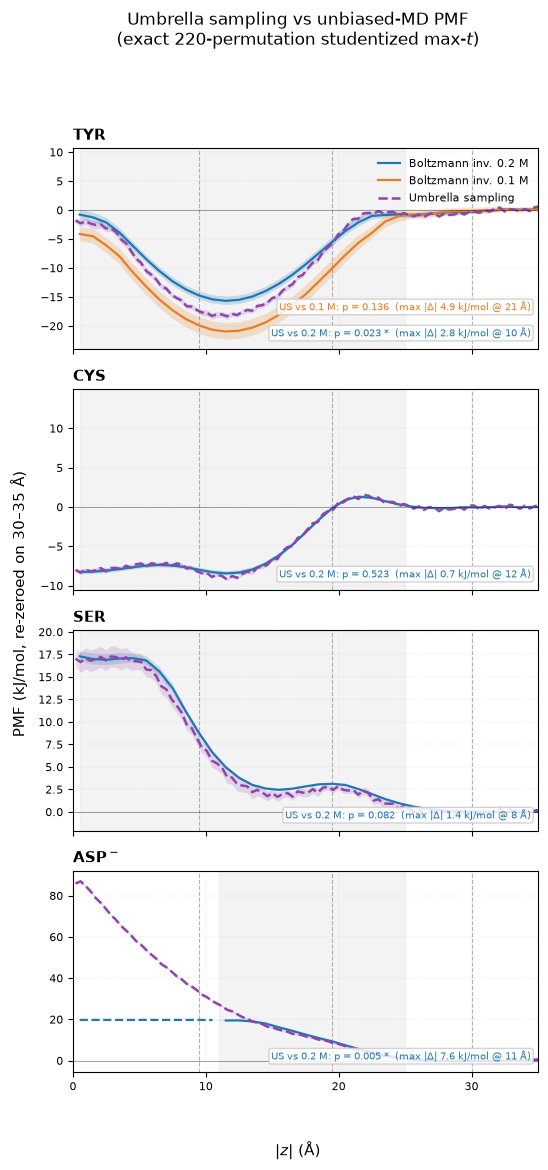

,analog,conc,md_code,plateau_end_A,lo,n_md,n_us,n_perm,T,zstar,gap_at_zstar_kJ,max_gap_kJ,z_max_gap,p_value
0,TYR,0.2 M,scy,0.0,0.5,9,3,220,4.508148,8.5,2.752642,2.830949,10.5,0.022727
1,TYR,0.1 M,scy-1,0.0,0.5,9,3,220,3.595013,22.0,4.227630,4.928572,21.0,0.136364
2,CYS,0.2 M,scc,0.0,0.5,9,3,220,2.074011,21.5,0.251002,0.656791,11.5,0.522727
3,SER,0.2 M,scs,0.0,0.5,9,3,220,4.061460,19.5,0.616419,1.364609,7.5,0.081818
4,ASP$^-$,0.2 M,scd,11.0,11.0,9,3,220,19.761669,11.0,7.572707,7.572707,11.0,0.004545


Saved: c:\Users\soeur\OneDrive\Documents\GitHub\Bories_and_Lague_2025\rev2\us_vs_md_pmf\figures\US_vs_MD_PMF_permutation.png


In [5]:
# A10 - Umbrella sampling vs unbiased-MD PMF, with exact permutation p-values (independent cell)
#
# One panel per analog, overlaying every available curve:
#   * Umbrella sampling (US)            : 3 block PMFs (block1/2/3, 3 x 50 ns)   [kcal -> kJ/mol]
#   * Boltzmann inversion, 0.2 M ("{sc}")   : 9 block PMFs = 3 trajectories x 3 time batches [kJ/mol]
#   * Boltzmann inversion, 0.1 M ("{sc}-1")  : 9 block PMFs, only where a -1 dataset exists
# Among the US analogs only TYR ("scy"/"scy-1") has a 0.1 M counterpart, so the
# third curve is drawn for TYR alone.
#
# For each overlaid MD curve a two-sample exact label-permutation test is run
# against the US ensemble (studentized omnibus max-|t|):
#   At each |z| bin, t(z) = |mean_MD(z) - mean_US(z)| / sqrt(var_MD/n_MD + var_US/n_US).
#   Statistic T = max_z |t(z)| over the informative membrane region
#   [plateau_end, 25] A (the outer plateau is excluded because re-zeroing drives
#   its between-block variance to ~0 and would inflate the studentized score).
#   Each curve is independently zeroed, then re-zeroed on the common far plateau
#   [30, 35] A so only shape is compared. The same C(12,3) = 220 label
#   assignments are applied jointly across bins, so one p-value controls the
#   family-wise error without a Bonferroni correction. Minimum p = 1/220 ~ 0.0045.
#
# Caveat: the 12 block curves are treated as exchangeable under the null; blocks
# within one MD trajectory and the three contiguous US blocks are not strictly
# independent, so the p-values are approximate convergence diagnostics.
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

KCAL_TO_KJ = 4.184
REZERO_LO, REZERO_HI = 30.0, 35.0   # common far plateau used to remove the offset nuisance
STAT_MAX_A = 25.0                   # upper |z| bound of the studentized test region
PLATEAU_SCAN_MAX_A = 20.0
GRID = np.arange(0.5, 35.0 + 1e-9, 0.5)
REGION_BOUNDS = [9.5, 19.5, 30.0]
US_COLOR = "#8e44ad"    # violet
MD02_COLOR = "tab:blue"
MD01_COLOR = "#e67e22"  # orange

# analog -> (display label, 0.2 M MD code, 0.1 M MD code or None)
US_ANALOGS = {
    "scy": ("TYR",       "scy", "scy-1"),
    "scc": ("CYS",       "scc", None),
    "scs": ("SER",       "scs", None),
    "scd": ("ASP$^-$",   "scd", None),
}

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/SUPP_umbrella_sampling/pmf").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

ROOT = find_repo_root()
DATA = ROOT / "figures/data"
OUT = ROOT / "rev2/us_vs_md_pmf"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

def plateau_end(md_code, z_max=PLATEAU_SCAN_MAX_A):
    """Upper |z| bound of the null-density plateau at z=0 (no MD sampling)."""
    path = DATA / "distribution_data/total" / md_code / f"summary_{md_code}.dat"
    if not path.is_file():
        return 0.0
    frame = pd.read_csv(path, sep=r"\s+")
    frame = frame[(frame["z"] >= 0) & (frame["z"] <= z_max)].sort_values("z").reset_index(drop=True)
    end = 0.0
    for _, row in frame.iterrows():
        if row["mean"] == 0:
            end = row["z"] + 0.5
        else:
            break
    return end

def rezero(z, y):
    mask = (z >= REZERO_LO) & (z <= REZERO_HI)
    return y - np.nanmean(y[mask]) if mask.any() else y

def md_block_curves(md_code):
    curves = []
    for trajectory in (1, 2, 3):
        path = DATA / "pmf_data/total" / md_code / f"trajectory{trajectory}.dat"
        if not path.is_file():
            continue
        frame = pd.read_csv(path, sep=r"\s+")
        z = frame["z"].to_numpy(float)
        for column in frame.columns[1:]:
            curves.append((z, rezero(z, frame[column].to_numpy(float))))
    return curves

def us_block_curves(us_code):
    curves = []
    for block in (1, 2, 3):
        path = DATA / "SUPP_umbrella_sampling/pmf" / us_code / f"block{block}" / f"pmf-us-{us_code}-block{block}.dat"
        arr = np.loadtxt(path)
        curves.append((arr[:, 0], rezero(arr[:, 0], arr[:, 1] * KCAL_TO_KJ)))
    return curves

def md_summary(md_code):
    frame = pd.read_csv(DATA / "pmf_data/total" / md_code / f"pmf_{md_code}.dat", sep=r"\s+")
    z = frame["z"].to_numpy(float)
    return z, rezero(z, frame["mean"].to_numpy(float)), frame["se"].to_numpy(float)

def us_summary(us_code):
    frame = pd.read_csv(DATA / "SUPP_umbrella_sampling/pmf" / us_code / f"pmf-us-{us_code}.dat",
                        sep=r"\s+", comment="#", header=None, usecols=[0, 1, 2])
    z = frame[0].to_numpy(float)
    return z, rezero(z, frame[1].to_numpy(float) * KCAL_TO_KJ), frame[2].to_numpy(float) * KCAL_TO_KJ

def interp_matrix(curves):
    return np.vstack([np.interp(GRID, z, y, left=np.nan, right=np.nan) for z, y in curves])

def permutation_maxt(md_matrix, us_matrix, lo):
    keep = (GRID >= lo) & (GRID <= STAT_MAX_A)
    grid = GRID[keep]
    md = md_matrix[:, keep]
    us = us_matrix[:, keep]
    good = np.isfinite(md).all(0) & np.isfinite(us).all(0)
    grid, md, us = grid[good], md[:, good], us[:, good]
    pooled = np.vstack([md, us])
    n_total, n_us = pooled.shape[0], us.shape[0]

    def studentized(us_index):
        mask = np.zeros(n_total, bool)
        mask[list(us_index)] = True
        us_group, md_group = pooled[mask], pooled[~mask]
        diff = md_group.mean(0) - us_group.mean(0)
        se = np.sqrt(md_group.var(0, ddof=1) / md_group.shape[0] + us_group.var(0, ddof=1) / us_group.shape[0])
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(se > 0, np.abs(diff) / se, 0.0)

    observed = studentized(range(md.shape[0], n_total))
    peak = int(np.argmax(observed))
    obs_t = float(observed[peak])
    null = np.array([float(studentized(combo).max()) for combo in combinations(range(n_total), n_us)])
    p_value = float((null >= obs_t - 1e-12).mean())
    mean_gap = np.abs(md.mean(0) - us.mean(0))
    return {
        "p_value": p_value, "T": obs_t, "zstar": float(grid[peak]),
        "gap_at_zstar_kJ": float(mean_gap[peak]), "max_gap_kJ": float(mean_gap.max()),
        "z_max_gap": float(grid[int(np.argmax(mean_gap))]),
        "n_perm": int(null.size), "n_md": int(md.shape[0]), "n_us": int(n_us), "lo": float(lo),
    }

def plot_md_curve(ax, md_code, color, label):
    pe = plateau_end(md_code)
    zq, yq, eq = md_summary(md_code)
    if pe > 0:
        solid = zq >= pe
        ax.plot(zq[solid], yq[solid], "-", color=color, lw=1.6, label=label)
        ax.plot(zq[zq <= pe], yq[zq <= pe], "--", color=color, lw=1.6)
    else:
        ax.plot(zq, yq, "-", color=color, lw=1.6, label=label)
    ax.fill_between(zq, yq - eq, yq + eq, color=color, alpha=0.20, linewidth=0)
    return pe

def draw_analog(ax, code):
    label, md02, md01 = US_ANALOGS[code]
    us_curves = us_block_curves(code)
    us_matrix = interp_matrix(us_curves)
    rows, annot = [], []

    # 0.2 M (always present for US analogs)
    pe02 = plot_md_curve(ax, md02, MD02_COLOR, "Boltzmann inv. 0.2 M")
    lo02 = max(pe02, GRID[0])
    s02 = permutation_maxt(interp_matrix(md_block_curves(md02)), us_matrix, lo02)
    rows.append({"analog": label, "conc": "0.2 M", "md_code": md02, "plateau_end_A": pe02, **s02})
    annot.append((MD02_COLOR, f"US vs 0.2 M: p = {s02['p_value']:.3f}" + (" *" if s02['p_value'] < 0.05 else "")
                  + f"  (max |\u0394| {s02['max_gap_kJ']:.1f} kJ/mol @ {s02['z_max_gap']:.0f} \u00c5)"))

    # 0.1 M (TYR only)
    if md01 is not None:
        pe01 = plot_md_curve(ax, md01, MD01_COLOR, "Boltzmann inv. 0.1 M")
        lo01 = max(pe01, GRID[0])
        s01 = permutation_maxt(interp_matrix(md_block_curves(md01)), us_matrix, lo01)
        rows.append({"analog": label, "conc": "0.1 M", "md_code": md01, "plateau_end_A": pe01, **s01})
        annot.append((MD01_COLOR, f"US vs 0.1 M: p = {s01['p_value']:.3f}" + (" *" if s01['p_value'] < 0.05 else "")
                      + f"  (max |\u0394| {s01['max_gap_kJ']:.1f} kJ/mol @ {s01['z_max_gap']:.0f} \u00c5)"))

    # US curve on top
    zu, yu, eu = us_summary(code)
    ax.plot(zu, yu, "--", color=US_COLOR, lw=1.8, label="Umbrella sampling")
    ax.fill_between(zu, yu - eu, yu + eu, color=US_COLOR, alpha=0.18, linewidth=0)

    ax.axvspan(lo02, STAT_MAX_A, color="0.85", alpha=0.30, zorder=0)
    for xv in REGION_BOUNDS:
        ax.axvline(xv, linestyle="--", alpha=0.6, linewidth=0.8, color="gray", zorder=0)
    ax.set_xlim(0, 35)
    ax.axhline(0.0, color="k", lw=0.5, alpha=0.5)
    ax.set_title(label, fontsize=11, fontweight="bold", loc="left")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.grid(True, which="major", linestyle="--", alpha=0.35, linewidth=0.3)
    ax.tick_params(axis="both", labelsize=8)

    y = 0.05
    for color, text in annot:
        ax.text(0.985, y, text, transform=ax.transAxes, ha="right", va="bottom",
                fontsize=7.5, color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.85))
        y += 0.13
    return rows

order = ["scy", "scc", "scs", "scd"]
fig, axes = plt.subplots(len(order), 1, figsize=(6, 3 * len(order)), sharex=True,
                         gridspec_kw={"hspace": 0.2})
summary_rows = []
for ax, code in zip(axes, order):
    summary_rows.extend(draw_analog(ax, code))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, fontsize=8, frameon=False, loc="upper right")
fig.suptitle("Umbrella sampling vs unbiased-MD PMF\n(exact 220-permutation studentized max-$t$)",
             fontsize=12, y=0.995)
fig.text(0.5, 0.04, "$|z|$ (\u00c5)", ha="center", fontsize=11)
fig.text(0.02, 0.5, "PMF (kJ/mol, re-zeroed on 30\u201335 \u00c5)", va="center", rotation="vertical", fontsize=11)
fig.tight_layout(rect=[0.04, 0.045, 1, 0.96])
fig.savefig(FIGURES / "US_vs_MD_PMF_permutation.pdf")
fig.savefig(FIGURES / "US_vs_MD_PMF_permutation.png", dpi=600, bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summary_rows)[
    ["analog", "conc", "md_code", "plateau_end_A", "lo", "n_md", "n_us", "n_perm",
     "T", "zstar", "gap_at_zstar_kJ", "max_gap_kJ", "z_max_gap", "p_value"]
]
summary.to_csv(OUT / "us_vs_md_permutation.csv", index=False)

report = [
    "# Umbrella sampling vs unbiased-MD PMF: permutation comparison",
    "",
    "One panel per analog overlays the US PMF with the 0.2 M and (TYR only) 0.1 M "
    "Boltzmann-inversion PMFs. Each block PMF is independently zeroed, then "
    f"re-zeroed on the common far plateau [{REZERO_LO:.0f}, {REZERO_HI:.0f}] A so "
    "only curve shape is compared. MD uses 9 block curves (3 trajectories x 3 time "
    "batches); US uses 3 block curves. The studentized omnibus max-|t| statistic is "
    f"evaluated over [plateau_end, {STAT_MAX_A:.0f}] A with the same C(12,3) = 220 "
    "exact label assignments applied jointly across bins (family-wise control). "
    "Minimum attainable p = 1/220 ~ 0.0045.",
    "",
]
for row in summary.itertuples(index=False):
    flag = " (significant at 0.05)" if row.p_value < 0.05 else ""
    report.append(
        f"- {row.analog} US vs {row.conc}: p = {row.p_value:.3f}{flag}; "
        f"max |delta| = {row.max_gap_kJ:.2f} kJ/mol at |z| = {row.z_max_gap:.1f} A "
        f"(T = {row.T:.2f} at {row.zstar:.1f} A)."
    )
report += [
    "",
    "Caveat: the 12 block curves are treated as exchangeable under the null; "
    "blocks within one MD trajectory and the three contiguous US blocks are not "
    "strictly independent, so p-values are approximate convergence diagnostics.",
]
(OUT / "REPORT.md").write_text("\n".join(report), encoding="utf-8")
display(summary)
print("Saved:", FIGURES / "US_vs_MD_PMF_permutation.png")


C:\Users\soeur\AppData\Local\Temp\ipykernel_23264\469674828.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.05, 1, 0.98])


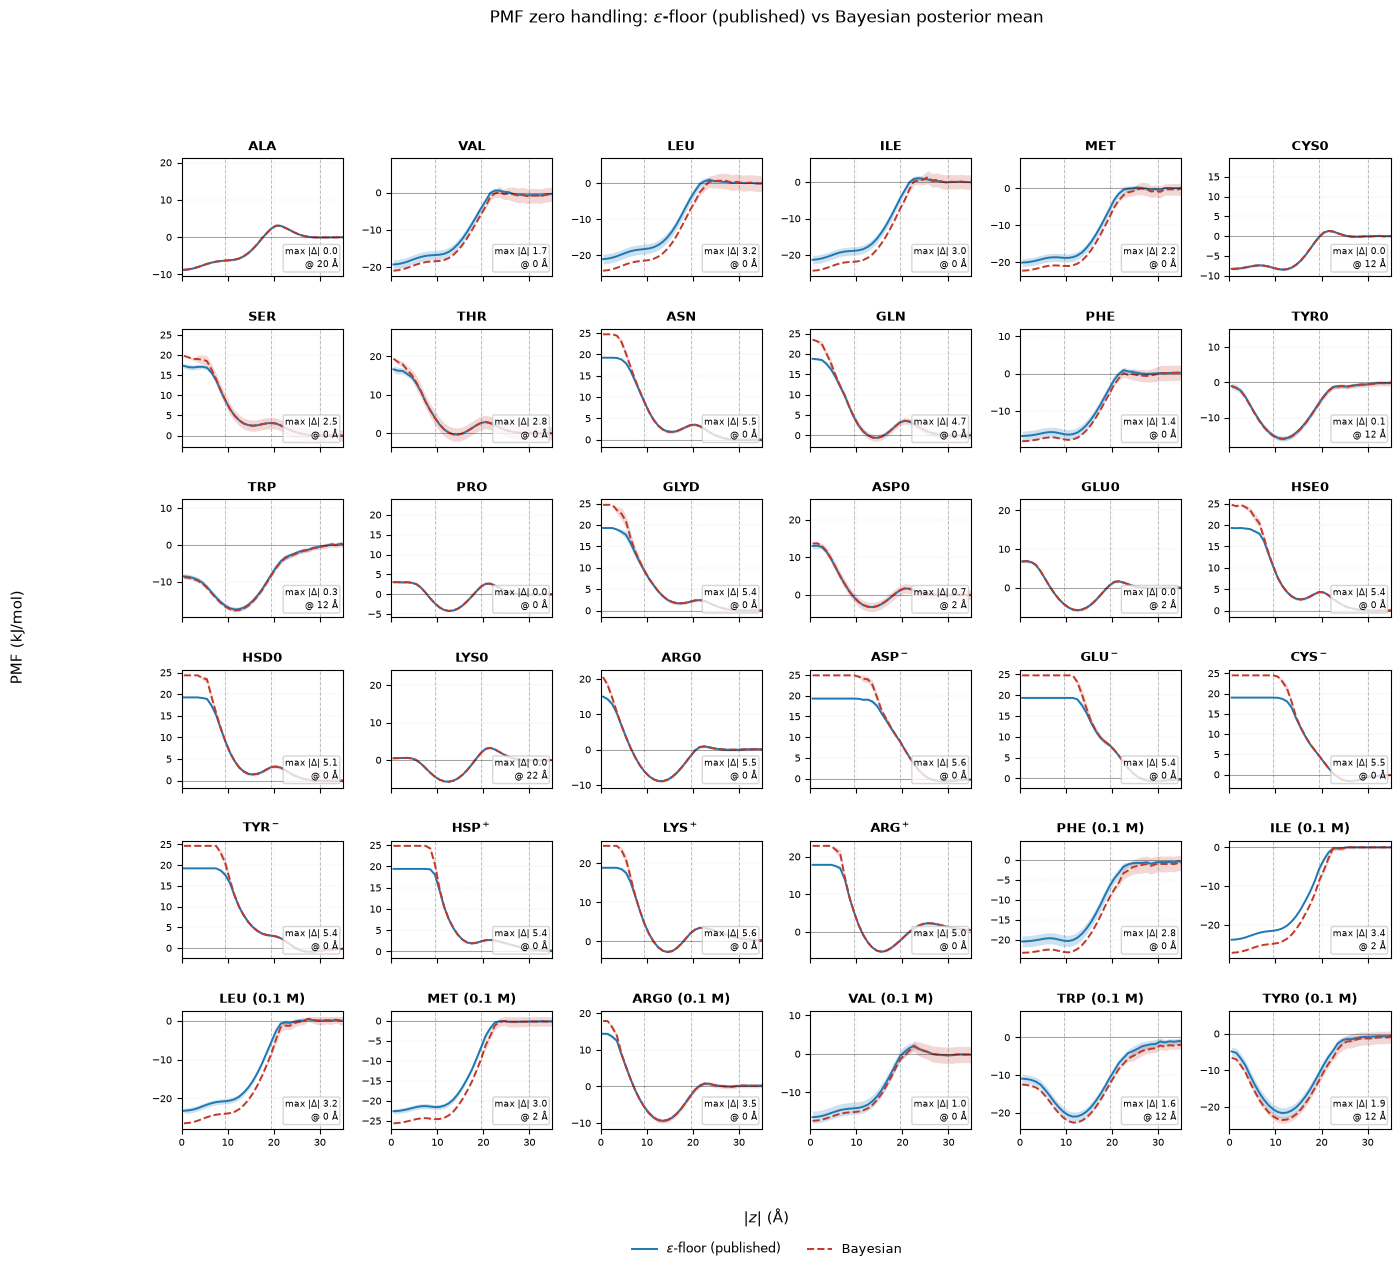

,analog,code,max_abs_diff_kJ,z_max_diff_A,rmsd_kJ
0,LYS$^+$,sck,5.609262,0.5,2.547188
1,ASP$^-$,scd,5.608333,0.5,4.069524
2,ARG0,scrn,5.541923,0.5,1.411068
3,ASN,scn,5.494943,0.5,2.372727
4,CYS$^-$,sccm,5.494631,0.5,3.794160
5,GLYD,glyd,5.416807,0.5,2.345828
6,HSP$^+$,schp,5.414821,0.5,3.254254
7,TYR$^-$,scym,5.414726,0.5,3.228974
8,GLU$^-$,sce,5.414372,0.5,3.878589
9,HSE0,sche,5.414208,0.5,2.426997


Saved: c:\Users\soeur\OneDrive\Documents\GitHub\Bories_and_Lague_2025\rev2\pmf_eps_vs_bayes\figures\PMF_eps_vs_bayes.png


In [14]:
# A11 - Published (epsilon-floor) vs Bayesian zero-handling PMF (independent cell)
#
# Compares, per analog, the PMF shipped in figures/data/pmf_data/total (computed
# with the -kT ln(p + epsilon) floor) against the PMF recomputed with the
# Dirichlet-multinomial posterior-mean zero handling in
# supp_files/method_script/4-pmf_calculation copy/total
# (Lovell, Chua & McGrath, NAR Genom. Bioinform. 2, lqaa040, 2020).
# Both curves share the same |z| grid; each panel overlays mean +/- SE and
# annotates the maximum |difference| over the sampled membrane region |z| <= 25 A.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

REGION_BOUNDS = [9.5, 19.5, 30.0]
COMPARE_MAX_A = 25.0
EPS_COLOR = "tab:blue"     # published epsilon-floor PMF
BAYES_COLOR = "#c0392b"    # Bayesian posterior-mean PMF

LABELS = {
    "sca": "ALA", "scv": "VAL", "scl": "LEU", "sci": "ILE", "scm": "MET",
    "scc": "CYS0", "scs": "SER", "sct": "THR", "scn": "ASN", "scq": "GLN",
    "scf": "PHE", "scy": "TYR0", "scw": "TRP", "scp": "PRO", "glyd": "GLYD",
    "scdn": "ASP0", "scen": "GLU0", "sche": "HSE0", "schd": "HSD0",
    "sckn": "LYS0", "scrn": "ARG0", "scd": "ASP$^-$", "sce": "GLU$^-$",
    "sccm": "CYS$^-$", "scym": "TYR$^-$", "schp": "HSP$^+$", "sck": "LYS$^+$",
    "scr": "ARG$^+$",
}

def label_for(code):
    if code.endswith("-1"):
        base = code[:-2]
        return f"{LABELS.get(base, base.upper())} (0.1 M)"
    return LABELS.get(code, code.upper())

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/pmf_data/total").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

ROOT = find_repo_root()
PUB_DIR = ROOT / "figures/data/pmf_data/total"
BAYES_DIR = ROOT / "supp_files/method_script/4-pmf_calculation copy/total"
OUT = ROOT / "rev2/pmf_eps_vs_bayes"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

def load_pmf(base, code):
    path = base / code / f"pmf_{code}.dat"
    if not path.is_file():
        return None
    frame = pd.read_csv(path, sep=r"\s+")
    return frame["z"].to_numpy(float), frame["mean"].to_numpy(float), frame["se"].to_numpy(float)

# order: dict order first, then any remaining common analogs (e.g. -1 variants)
pub_codes = {p.name for p in PUB_DIR.iterdir() if p.is_dir()}
bayes_codes = {p.name for p in BAYES_DIR.iterdir() if p.is_dir()}
common = pub_codes & bayes_codes
ordered = [c for c in LABELS if c in common] + sorted(c for c in common if c not in LABELS)

n = len(ordered)
ncols = 6
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.1 * nrows),
                         sharex=True, gridspec_kw={"hspace": 0.45, "wspace": 0.3})
axes_flat = np.atleast_1d(axes).ravel()

summary_rows, legend_ax = [], None
for ax, code in zip(axes_flat, ordered):
    pub = load_pmf(PUB_DIR, code)
    bay = load_pmf(BAYES_DIR, code)
    zp, yp, ep = pub
    zb, yb, eb = bay
    ax.plot(zp, yp, "-", color=EPS_COLOR, lw=1.4, label=r"$\varepsilon$-floor (published)")
    ax.fill_between(zp, yp - ep, yp + ep, color=EPS_COLOR, alpha=0.22, linewidth=0)
    ax.plot(zb, yb, "--", color=BAYES_COLOR, lw=1.4, label="Bayesian")
    ax.fill_between(zb, yb - eb, yb + eb, color=BAYES_COLOR, alpha=0.20, linewidth=0)

    # max |difference| on the shared grid over the sampled membrane region
    if np.array_equal(zp, zb):
        reg = zp <= COMPARE_MAX_A
        diff = np.abs(yp - yb)[reg]
        max_gap = float(diff.max())
        z_at = float(zp[reg][int(np.argmax(diff))])
        rmsd = float(np.sqrt(np.mean((yp - yb)[reg] ** 2)))
    else:
        grid = np.union1d(zp, zb)
        gi = (grid <= COMPARE_MAX_A)
        di = np.abs(np.interp(grid, zp, yp) - np.interp(grid, zb, yb))[gi]
        max_gap = float(di.max()); z_at = float(grid[gi][int(np.argmax(di))])
        rmsd = float(np.sqrt(np.mean(di ** 2)))
    summary_rows.append({"analog": label_for(code), "code": code,
                         "max_abs_diff_kJ": max_gap, "z_max_diff_A": z_at, "rmsd_kJ": rmsd})

    ax.text(0.97, 0.05, f"max |\u0394| {max_gap:.1f}\n@ {z_at:.0f} \u00c5",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=6.5,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.8))
    for xv in REGION_BOUNDS:
        ax.axvline(xv, linestyle="--", alpha=0.5, linewidth=0.7, color="gray", zorder=0)
    ax.axhline(0.0, color="k", lw=0.5, alpha=0.5)
    ax.set_xlim(0, 35)
    ax.set_title(label_for(code), fontsize=9, fontweight="bold")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.grid(True, which="major", linestyle="--", alpha=0.3, linewidth=0.3)
    ax.tick_params(axis="both", labelsize=7)
    if legend_ax is None:
        legend_ax = ax

for ax in axes_flat[n:]:
    ax.axis("off")

if legend_ax is not None:
    h, l = legend_ax.get_legend_handles_labels()
    fig.legend(h, l, fontsize=9, frameon=False, loc="lower center",
               ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("PMF zero handling: $\\varepsilon$-floor (published) vs Bayesian posterior mean",
             fontsize=12, y=0.998)
fig.text(0.5, 0.035, "$|z|$ (\u00c5)", ha="center", fontsize=11)
fig.text(0.015, 0.5, "PMF (kJ/mol)", va="center", rotation="vertical", fontsize=11)
fig.tight_layout(rect=[0.03, 0.05, 1, 0.98])
fig.savefig(FIGURES / "PMF_eps_vs_bayes.pdf")
fig.savefig(FIGURES / "PMF_eps_vs_bayes.png", dpi=600, bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summary_rows).sort_values("max_abs_diff_kJ", ascending=False).reset_index(drop=True)
summary.to_csv(OUT / "pmf_eps_vs_bayes_summary.csv", index=False)
display(summary)
print("Saved:", FIGURES / "PMF_eps_vs_bayes.png")


C:\Users\soeur\AppData\Local\Temp\ipykernel_23264\3804512141.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.97])


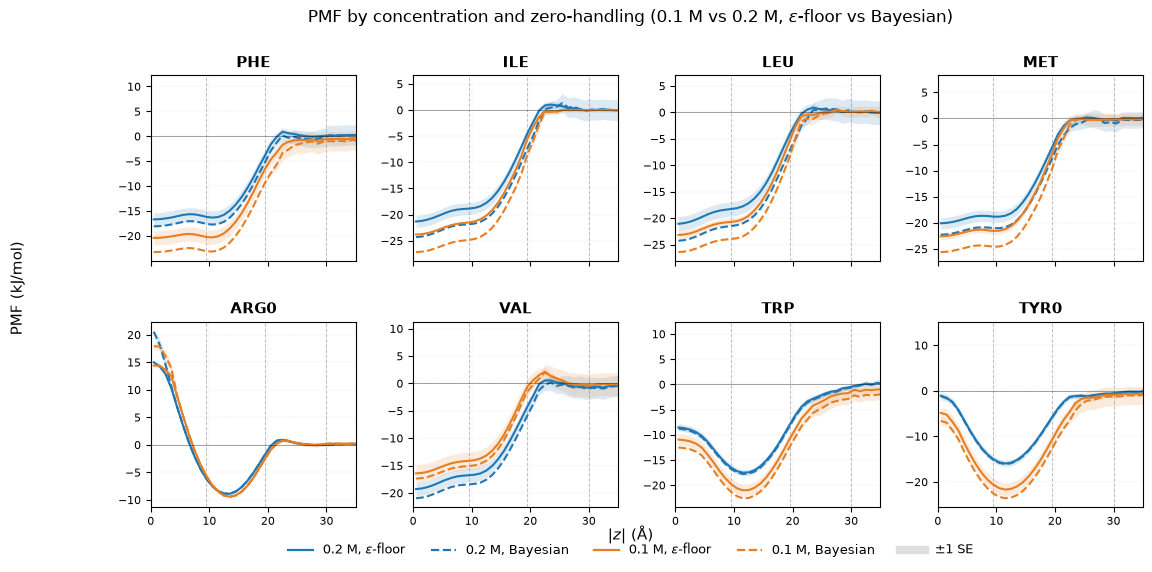

Saved: c:\Users\soeur\OneDrive\Documents\GitHub\Bories_and_Lague_2025\rev2\pmf_conc_eps_vs_bayes\figures\PMF_conc_eps_vs_bayes.png


In [16]:
# A12 - Concentration x zero-handling PMF overlay for the -1 sidechains (independent cell)
#
# For each sidechain that has a 0.1 M ("{code}-1") counterpart, overlay four PMFs:
#   * 0.1 M, epsilon-floor      (figures/data/pmf_data/total/{code}-1)
#   * 0.2 M, epsilon-floor      (figures/data/pmf_data/total/{code})
#   * 0.1 M, Bayesian           (4-pmf_calculation copy/total/{code}-1)
#   * 0.2 M, Bayesian           (4-pmf_calculation copy/total/{code})
# Concentration is encoded by colour (0.1 M vs 0.2 M) and the zero-handling
# method by line style (epsilon = solid, Bayesian = dashed). Shaded bands show
# +/- 1 SE (block-to-block standard error). Both methods are recalibrated on the
# same [40, 50] A bulk window, so the curves are comparable.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

REGION_BOUNDS = [9.5, 19.5, 30.0]
C01_COLOR = "#e67e22"   # 0.1 M  (orange)
C02_COLOR = "tab:blue"  # 0.2 M  (blue)

# base code -> residue label (the "-1" code is the same residue at 0.1 M)
BASES = {
    "scf": "PHE", "sci": "ILE", "scl": "LEU", "scm": "MET",
    "scrn": "ARG0", "scv": "VAL", "scw": "TRP", "scy": "TYR0",
}

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/pmf_data/total").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

ROOT = find_repo_root()
EPS_DIR = ROOT / "figures/data/pmf_data/total"
BAYES_DIR = ROOT / "supp_files/method_script/4-pmf_calculation copy/total"
OUT = ROOT / "rev2/pmf_conc_eps_vs_bayes"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

def load_pmf(base, code):
    path = base / code / f"pmf_{code}.dat"
    if not path.is_file():
        return None
    frame = pd.read_csv(path, sep=r"\s+")
    return frame["z"].to_numpy(float), frame["mean"].to_numpy(float), frame["se"].to_numpy(float)

order = list(BASES)
ncols = 4
nrows = int(np.ceil(len(order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows),
                         sharex=True, gridspec_kw={"hspace": 0.33, "wspace": 0.28})
axes_flat = np.atleast_1d(axes).ravel()

# (directory, concentration code suffix, color, linestyle, label)
SERIES = [
    (EPS_DIR,   "",   C02_COLOR, "-",  "0.2 M, $\\varepsilon$-floor"),
    (BAYES_DIR, "",   C02_COLOR, "--", "0.2 M, Bayesian"),
    (EPS_DIR,   "-1", C01_COLOR, "-",  "0.1 M, $\\varepsilon$-floor"),
    (BAYES_DIR, "-1", C01_COLOR, "--", "0.1 M, Bayesian"),
]

for ax, base in zip(axes_flat, order):
    for directory, suffix, color, ls, _ in SERIES:
        data = load_pmf(directory, base + suffix)
        if data is None:
            continue
        z, y, se = data
        ax.fill_between(z, y - se, y + se, color=color, alpha=0.15, linewidth=0)
        ax.plot(z, y, ls, color=color, lw=1.5)
    for xv in REGION_BOUNDS:
        ax.axvline(xv, linestyle="--", alpha=0.5, linewidth=0.7, color="gray", zorder=0)
    ax.axhline(0.0, color="k", lw=0.5, alpha=0.5)
    ax.set_xlim(0, 35)
    ax.set_title(BASES[base], fontsize=11, fontweight="bold")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.grid(True, which="major", linestyle="--", alpha=0.3, linewidth=0.3)
    ax.tick_params(axis="both", labelsize=8)

for ax in axes_flat[len(order):]:
    ax.axis("off")

legend_handles = [Line2D([0], [0], color=c, ls=ls, lw=1.6, label=lab)
                  for _, _, c, ls, lab in SERIES]
legend_handles.append(Line2D([0], [0], color="0.5", lw=6, alpha=0.25, label="$\\pm$1 SE"))
fig.legend(handles=legend_handles, fontsize=9, frameon=False, loc="lower center",
           ncol=5, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("PMF by concentration and zero-handling (0.1 M vs 0.2 M, $\\varepsilon$-floor vs Bayesian)",
             fontsize=12, y=0.998)
fig.text(0.5, 0.05, "$|z|$ (\u00c5)", ha="center", fontsize=11)
fig.text(0.015, 0.5, "PMF (kJ/mol)", va="center", rotation="vertical", fontsize=11)
fig.tight_layout(rect=[0.03, 0.06, 1, 0.97])
fig.savefig(FIGURES / "PMF_conc_eps_vs_bayes.pdf")
fig.savefig(FIGURES / "PMF_conc_eps_vs_bayes.png", dpi=600, bbox_inches="tight")
plt.show()
print("Saved:", FIGURES / "PMF_conc_eps_vs_bayes.png")


C:\Users\soeur\AppData\Local\Temp\ipykernel_23264\3671619631.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.97])


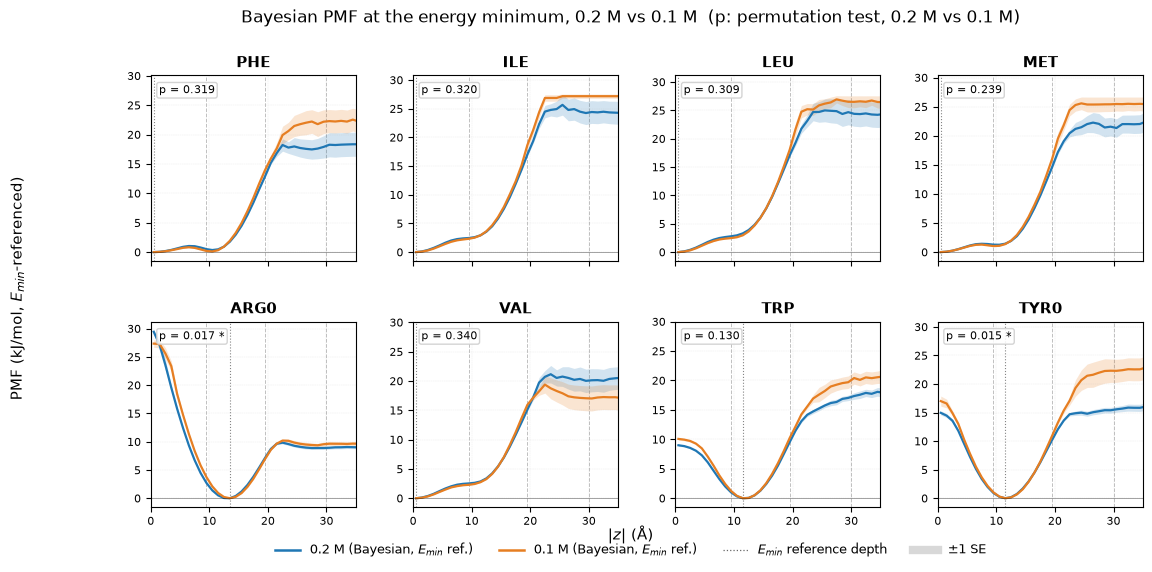

,analog,code,p_value,T
0,PHE,scf,0.319168,1.531912
1,ILE,sci,0.319968,1.527717
2,LEU,scl,0.308969,1.662899
3,MET,scm,0.238676,1.944404
4,ARG0,scrn,0.017398,3.938919
5,VAL,scv,0.339866,1.458120
6,TRP,scw,0.130287,2.257306
7,TYR0,scy,0.014799,3.274713


Saved: c:\Users\soeur\OneDrive\Documents\GitHub\Bories_and_Lague_2025\rev2\pmf_bayes_emin\figures\PMF_bayes_emin_conc.png


In [19]:
# A13 - Bayesian PMF referenced at the energy minimum (0.2 M vs 0.1 M), with SE
#        and a 0.2 M-vs-0.1 M permutation p-value
#
# For each sidechain that has a 0.1 M ("{code}-1") counterpart, plot the Bayesian
# PMF referenced at the energy-minimum depth (files pmf_{code}_emin.dat, i.e. the
# mean BEFORE the bulk [40,50] A shift), at both concentrations, with +/- 1 SE
# bands. The common reference is the argmin of the across-replica mean PMF (the
# most-populated depth), applied identically to all 9 replicas, so every curve
# passes through 0 at that depth and the SE grows outward from it.
#
# p-value: two-sample exact-style permutation test of whether the 0.2 M and
# 0.1 M PMFs differ. The nine 0.2 M block PMFs ({code}) and nine 0.1 M block
# PMFs ({code}-1) (3 trajectories x 3 time batches each) are interpolated to a
# common grid, re-zeroed on [30,35] A, and compared with a studentized omnibus
# max-|t| statistic over [0.5, 25] A; the 18 concentration labels are permuted
# into 9+9 (Monte-Carlo, fixed seed) and the single p-value controls the
# family-wise error across bins. Caveat: the 18 block curves are treated as
# exchangeable under the null, so p is an approximate convergence diagnostic.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from IPython.display import display

REGION_BOUNDS = [9.5, 19.5, 30.0]
C01_COLOR = "#e67e22"   # 0.1 M  (orange)
C02_COLOR = "tab:blue"  # 0.2 M  (blue)

# permutation-test settings
PERM_GRID = np.arange(0.5, 35.0 + 1e-9, 0.5)
REZERO_LO, REZERO_HI = 30.0, 35.0
STAT_MAX_A = 25.0
N_PERM = 10000
PERM_SEED = 0

BASES = {
    "scf": "PHE", "sci": "ILE", "scl": "LEU", "scm": "MET",
    "scrn": "ARG0", "scv": "VAL", "scw": "TRP", "scy": "TYR0",
}

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "figures/data/pmf_data/total").is_dir():
            return base
    raise FileNotFoundError("Run from within the Bories_and_Lague_2025 repository")

ROOT = find_repo_root()
BAYES_DIR = ROOT / "supp_files/method_script/4-pmf_calculation copy/total"
OUT = ROOT / "rev2/pmf_bayes_emin"
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

def load_pmf_emin(code):
    path = BAYES_DIR / code / f"pmf_{code}_emin.dat"
    if not path.is_file():
        return None
    frame = pd.read_csv(path, sep=r"\s+")
    return frame["z"].to_numpy(float), frame["mean"].to_numpy(float), frame["se"].to_numpy(float)

def block_curves(code):
    """Nine block PMFs (3 trajectories x 3 time batches) on PERM_GRID, re-zeroed on [30,35]."""
    rows = []
    for traj in (1, 2, 3):
        path = BAYES_DIR / code / f"trajectory{traj}.dat"
        if not path.is_file():
            continue
        arr = np.loadtxt(path, skiprows=1)
        z = arr[:, 0]
        for b in range(1, arr.shape[1]):
            y = np.interp(PERM_GRID, z, arr[:, b], left=np.nan, right=np.nan)
            mask = (PERM_GRID >= REZERO_LO) & (PERM_GRID <= REZERO_HI)
            rows.append(y - np.nanmean(y[mask]))
    return np.array(rows)

def permutation_pvalue(group_a, group_b):
    """Two-sample studentized omnibus max-|t| permutation p-value over [0.5, STAT_MAX]."""
    keep = (PERM_GRID >= PERM_GRID[0]) & (PERM_GRID <= STAT_MAX_A)
    pooled = np.vstack([group_a, group_b])[:, keep]
    good = np.isfinite(pooled).all(0)
    pooled = pooled[:, good]
    n_total, n_b = pooled.shape[0], group_b.shape[0]
    n_a = n_total - n_b

    def max_t(mask):
        gb, ga = pooled[mask], pooled[~mask]
        diff = ga.mean(0) - gb.mean(0)
        se = np.sqrt(ga.var(0, ddof=1) / n_a + gb.var(0, ddof=1) / n_b)
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(se > 0, np.abs(diff) / se, 0.0).max()

    obs_mask = np.zeros(n_total, bool); obs_mask[group_a.shape[0]:] = True
    obs = max_t(obs_mask)

    rng = np.random.default_rng(PERM_SEED)
    membership = np.zeros((N_PERM, n_total))
    for i in range(N_PERM):
        membership[i, rng.permutation(n_total)[:n_b]] = 1.0
    sB = membership @ pooled; sB2 = membership @ (pooled ** 2)
    sA = (1 - membership) @ pooled; sA2 = (1 - membership) @ (pooled ** 2)
    mB, mA = sB / n_b, sA / n_a
    vB = (sB2 - n_b * mB ** 2) / (n_b - 1); vA = (sA2 - n_a * mA ** 2) / (n_a - 1)
    se = np.sqrt(vA / n_a + vB / n_b)
    with np.errstate(divide="ignore", invalid="ignore"):
        null = np.where(se > 0, np.abs(mA - mB) / se, 0.0).max(axis=1)
    p_value = (1 + int(np.sum(null >= obs - 1e-12))) / (1 + N_PERM)
    return p_value, float(obs)

order = list(BASES)
ncols = 4
nrows = int(np.ceil(len(order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows),
                         sharex=True, gridspec_kw={"hspace": 0.33, "wspace": 0.28})
axes_flat = np.atleast_1d(axes).ravel()

SERIES = [
    ("",   C02_COLOR, "0.2 M (Bayesian, $E_{min}$ ref.)"),
    ("-1", C01_COLOR, "0.1 M (Bayesian, $E_{min}$ ref.)"),
]
summary_rows = []
for ax, base in zip(axes_flat, order):
    ref_zs = []
    for suffix, color, _ in SERIES:
        data = load_pmf_emin(base + suffix)
        if data is None:
            continue
        z, y, se = data
        ax.fill_between(z, y - se, y + se, color=color, alpha=0.20, linewidth=0)
        ax.plot(z, y, "-", color=color, lw=1.6)
        ref_zs.append(z[int(np.argmin(y))])
    if ref_zs:
        ax.axvline(ref_zs[0], color="0.4", lw=0.8, ls=":", alpha=0.8, zorder=1)

    # 0.2 M vs 0.1 M permutation test
    p_value, T = permutation_pvalue(block_curves(base), block_curves(base + "-1"))
    summary_rows.append({"analog": BASES[base], "code": base, "p_value": p_value, "T": T})
    ax.text(0.04, 0.95, f"p = {p_value:.3f}" + (" *" if p_value < 0.05 else ""),
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.85))

    for xv in REGION_BOUNDS:
        ax.axvline(xv, linestyle="--", alpha=0.5, linewidth=0.7, color="gray", zorder=0)
    ax.axhline(0.0, color="k", lw=0.5, alpha=0.5)
    ax.set_xlim(0, 35)
    ax.set_title(BASES[base], fontsize=11, fontweight="bold")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.grid(True, which="major", linestyle="--", alpha=0.3, linewidth=0.3)
    ax.tick_params(axis="both", labelsize=8)

for ax in axes_flat[len(order):]:
    ax.axis("off")

legend_handles = [Line2D([0], [0], color=c, lw=1.8, label=lab) for _, c, lab in SERIES]
legend_handles.append(Line2D([0], [0], color="0.4", lw=0.9, ls=":", label="$E_{min}$ reference depth"))
legend_handles.append(Line2D([0], [0], color="0.5", lw=6, alpha=0.3, label="$\\pm$1 SE"))
fig.legend(handles=legend_handles, fontsize=9, frameon=False, loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Bayesian PMF at the energy minimum, 0.2 M vs 0.1 M  (p: permutation test, 0.2 M vs 0.1 M)",
             fontsize=12, y=0.998)
fig.text(0.5, 0.05, "$|z|$ (\u00c5)", ha="center", fontsize=11)
fig.text(0.015, 0.5, "PMF (kJ/mol, $E_{min}$-referenced)", va="center", rotation="vertical", fontsize=11)
fig.tight_layout(rect=[0.03, 0.06, 1, 0.97])
fig.savefig(FIGURES / "PMF_bayes_emin_conc.pdf")
fig.savefig(FIGURES / "PMF_bayes_emin_conc.png", dpi=600, bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT / "pmf_bayes_emin_permutation.csv", index=False)
display(summary)
print("Saved:", FIGURES / "PMF_bayes_emin_conc.png")
